In [1]:
import matplotlib.pyplot as plt
import json
import os
import numpy as np
import pandas as pd
from tabulate import tabulate

In [2]:
PATH = "/home/ray/Documents/icccn-lstm/devs/lstm/"
TYPES = {"lstm": "LSTM", "gru": "GRU", "rnn": "SimpleRNN"}
RATS = {"dsrc": "DSRC", "pc5": "C-V2X PC5", "5g": "5G SA"}


In [3]:
def plot_losses(types, rats):

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
    i, j = 0, 0

    for rat in rats:
        for type in types:
            with open(os.path.join(PATH, type + "_" + rat + "_training_history.json"), "r") as f:
                history = json.load(f)
                epochs = np.arange(len(history['loss']))  # Assuming loss has same length as RMSE

                ax = axes[i, j]
                twin_ax = ax.twinx()

                # Plot RMSE curves
                ax.plot(epochs, np.sqrt(history["latency_ms_rmse"]), label="Latency RMSE", color="blue", linestyle="-")
                ax.plot(epochs, np.sqrt(history["val_latency_ms_rmse"]), label="Val Latency RMSE", color="blue", linestyle="dashed")

                twin_ax.plot(epochs, np.sqrt(history["pdr_rmse"]), label="PDR RMSE", color="red", linestyle="-")
                twin_ax.plot(epochs, np.sqrt(history["val_pdr_rmse"]), label="Val PDR RMSE", color="red", linestyle="dashed")

                # Labels and formatting
                ax.set_title(rats[rat] + " - " + types[type])
                ax.set_xlabel("Epochs")
                ax.set_ylabel("Latency RMSE (ms)", color="black")
                twin_ax.set_ylabel("PDR RMSE (%)", color="black")

                ax.tick_params(axis='y', colors='black')
                twin_ax.tick_params(axis='y', colors='black')

                # Adjust PDR and Latency RMSE axis limits
                if rat == "5g":
                    twin_ax.set_ylim(0, 0.52)  # 5G SA PDR RMSE range
                    ax.set_ylim(0.4, 2)
                elif rat == "dsrc":
                    twin_ax.set_ylim(0, 0.52)  # DSRC & C-V2X PDR RMSE range
                    ax.set_ylim(0.04, 0.11)
                elif rat == "pc5":
                    twin_ax.set_ylim(0, 0.52)  # DSRC & C-V2X PDR RMSE range
                    ax.set_ylim(0.42, 0.52)

                # Legend
                ax.legend(loc="upper left", fontsize=8)
                twin_ax.legend(loc="upper right", fontsize=8)

            j += 1
        i += 1
        j= 0

    fig.suptitle("Training vs Validation Loss (RMSE)")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(PATH,"training_loss_grid.png"), dpi=600)
    fig.show()


def table_epochs(types, rats):
    summary_data = []
    i, j = 0, 0

    for rat in rats:
        for type in types:
            file_idx = i * 3 + j  # Map row/col to file index
            df = pd.read_csv(os.path.join(PATH, type + "_" + rat + "_training_log.csv"))

            # Extract summary statistics
            pdr_train_loss_final = df["Train Loss (PDR)"].iloc[-1]
            pdr_val_loss_final = df["Val Loss (PDR)"].iloc[-1]
            pdr_train_rmse_final = df["Train RMSE (PDR)"].iloc[-1]
            pdr_val_rmse_final = df["Val RMSE (PDR)"].iloc[-1]

            pdr_best_idx = df["Val RMSE (PDR)"].idxmin()  # Best epoch (lowest val loss)
            pdr_best_val_loss = df["Val Loss (PDR)"].iloc[pdr_best_idx]
            pdr_best_val_rmse = df["Val RMSE (PDR)"].min()


            latency_train_loss_final = df["Train Loss (Latency)"].iloc[-1]
            latency_val_loss_final = df["Val Loss (Latency)"].iloc[-1]
            latency_train_rmse_final = df["Train RMSE (Latency)"].iloc[-1]
            latency_val_rmse_final = df["Val RMSE (Latency)"].iloc[-1]

            latency_best_idx = df["Val RMSE (Latency)"].idxmin()  # Best epoch (lowest val loss)
            latency_best_val_loss = df["Val Loss (Latency)"].iloc[latency_best_idx]
            latency_best_val_rmse = df["Val RMSE (Latency)"].min()

            best_epoch = df["Epoch"].iloc[latency_best_idx]
            avg_epoch_time = df["Time (seconds)"].mean()
            fastest_training_time = df["Time (seconds)"].min()
            total_training_time = df["Time (seconds)"].sum()
            max_epoch = df["Epoch"].max()


            # Store results
            summary_data.append([
                rat, type, max_epoch, best_epoch, latency_best_val_loss, latency_best_val_rmse,
                latency_train_loss_final, latency_val_loss_final, latency_train_rmse_final, latency_val_rmse_final,
                pdr_best_val_loss, pdr_best_val_rmse, pdr_train_loss_final, pdr_val_loss_final, pdr_train_rmse_final,
                pdr_val_rmse_final, avg_epoch_time, fastest_training_time, total_training_time
            ])

            j += 1
        i += 1
        j= 0

    # Create DataFrame
    summary_df = pd.DataFrame(summary_data, columns=[
        "RAT", "Model type", "Max Epoch", "Best Epoch", "Best Val Loss (Latency)", "Best Val RMSE (Latency)",
        "Train Loss (Latency)", "Val Loss (Latency)", "Train RMSE (Latency)", "Val RMSE (Latency)",
        "Best Val Loss (PDR)", "Best Val RMSE (PDR)", "Train Loss (PDR)", "Val Loss (PDR)", "Train RMSE (PDR)",
        "Val RMSE (PDR)", "Avg Epoch Time (s)", "Fastest Training Time (s)", "Total Training Time (s)"
    ])

    # Display nicely formatted table in Jupyter
    summary_df.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center')]}]
    )

    summary_df.to_csv(os.path.join(PATH, "epoch_summary_table.csv"), index=False)

    return summary_df



In [4]:
epoch_table = table_epochs(TYPES, RATS)
print(tabulate(epoch_table, headers="keys", tablefmt="github"))


FileNotFoundError: [Errno 2] No such file or directory: '/home/ray/Documents/icccn-lstm/devs/lstm/lstm_dsrc_training_log.csv'

In [ ]:
    # Plot losses
plot_losses(TYPES, RATS)


In [5]:
# =============================================================================
# Pipeline Results Analysis
# =============================================================================
# Focus on latest mature pipelines (pipeline_5, pipeline_6 = 20 vehicles)
# pipeline_3 = 5 vehicles baseline for scalability comparison

from pathlib import Path
import matplotlib.ticker as mticker
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.figsize": (8, 5),
    "savefig.bbox": "tight",
})

OUT = Path(PATH) / "output"
FIG = Path(PATH) / "figures"
FIG.mkdir(exist_ok=True)

# Load latest pipeline data
LATEST = "pipeline_6"
PIPELINES = {
    "pipeline_3": {"label": "N=5 vehicles",  "n": 5},
    "pipeline_5": {"label": "N=20 (v5)",     "n": 20},
    "pipeline_6": {"label": "N=20 (v6)",     "n": 20},
}

RAT_COLORS = {"5g": "#1f77b4", "pc5": "#ff7f0e", "dsrc": "#2ca02c"}
RAT_LABELS = {"5g": "5G SA", "pc5": "C-V2X PC5", "dsrc": "DSRC"}


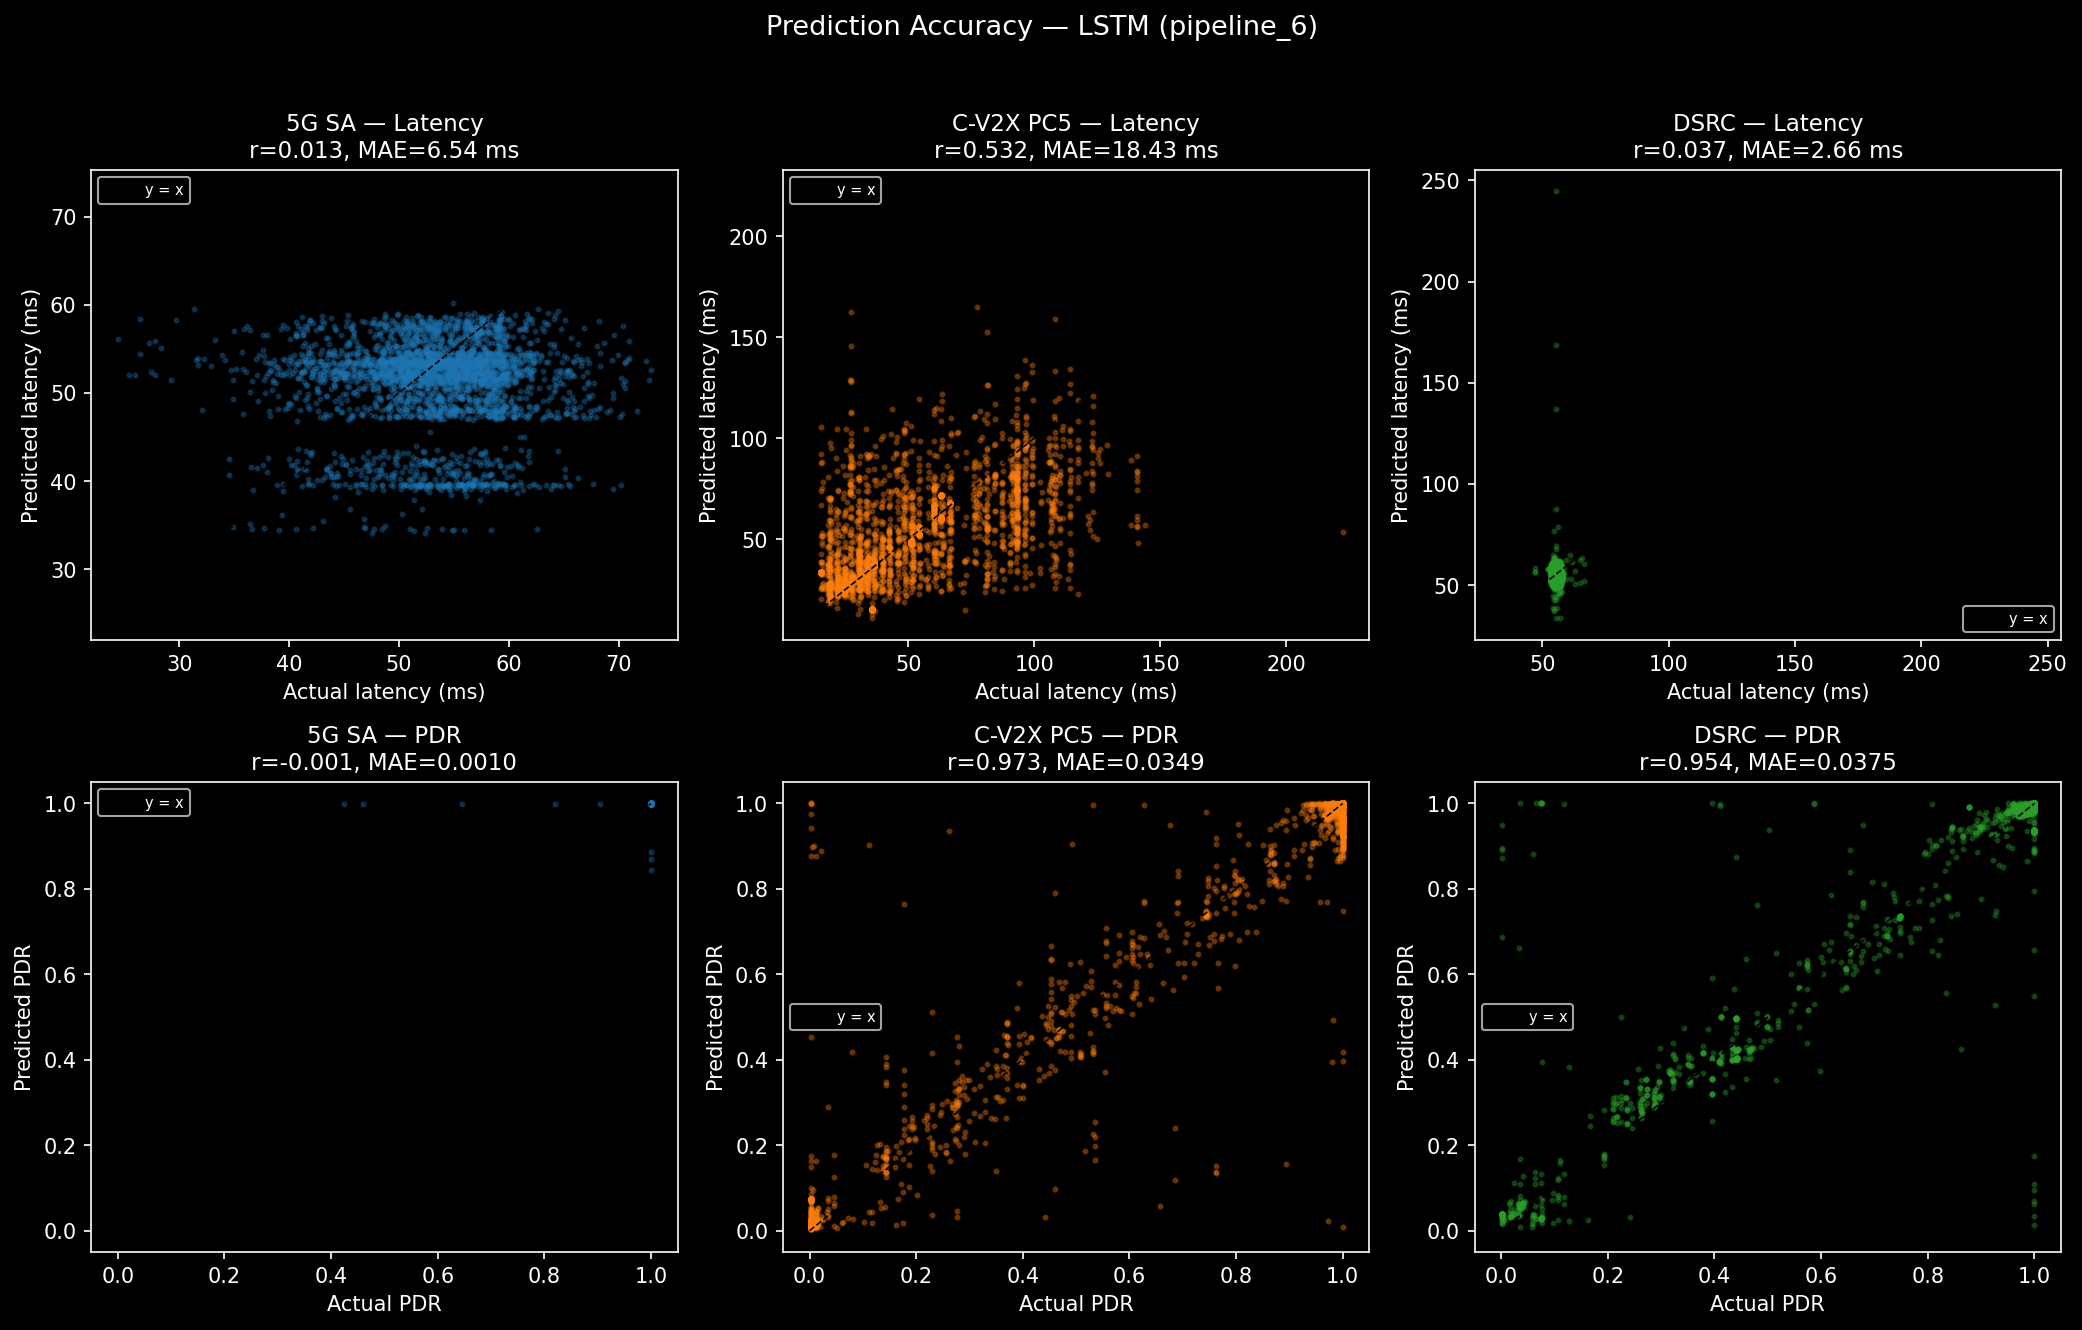

In [6]:
# ── Figure 1: Prediction Accuracy — Actual vs Predicted (scatter + density) ──
# Uses final_log from the latest pipeline for each RAT

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for j, rat in enumerate(["5g", "pc5", "dsrc"]):
    flog = pd.read_csv(OUT / LATEST / f"final_log_lstm_{rat}.csv")

    # -- Latency scatter (top row) --
    ax = axes[0, j]
    ax.scatter(flog["actual_latency"], flog["pred_latency"],
               s=4, alpha=0.3, color=RAT_COLORS[rat])
    lo = min(flog["actual_latency"].min(), flog["pred_latency"].min())
    hi = max(flog["actual_latency"].max(), flog["pred_latency"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="y = x")
    r, _ = stats.pearsonr(flog["actual_latency"], flog["pred_latency"])
    mae = flog["mae_latency"].mean()
    ax.set_title(f"{RAT_LABELS[rat]} — Latency\nr={r:.3f}, MAE={mae:.2f} ms")
    ax.set_xlabel("Actual latency (ms)")
    ax.set_ylabel("Predicted latency (ms)")
    ax.legend(fontsize=7)

    # -- PDR scatter (bottom row) --
    ax = axes[1, j]
    ax.scatter(flog["actual_pdr"], flog["pred_pdr"],
               s=4, alpha=0.3, color=RAT_COLORS[rat])
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="y = x")
    r_pdr, _ = stats.pearsonr(flog["actual_pdr"], flog["pred_pdr"])
    mae_pdr = flog["mae_pdr"].mean()
    ax.set_title(f"{RAT_LABELS[rat]} — PDR\nr={r_pdr:.3f}, MAE={mae_pdr:.4f}")
    ax.set_xlabel("Actual PDR")
    ax.set_ylabel("Predicted PDR")
    ax.legend(fontsize=7)

fig.suptitle(f"Prediction Accuracy — LSTM ({LATEST})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG / "fig1_prediction_accuracy.png")
plt.show()


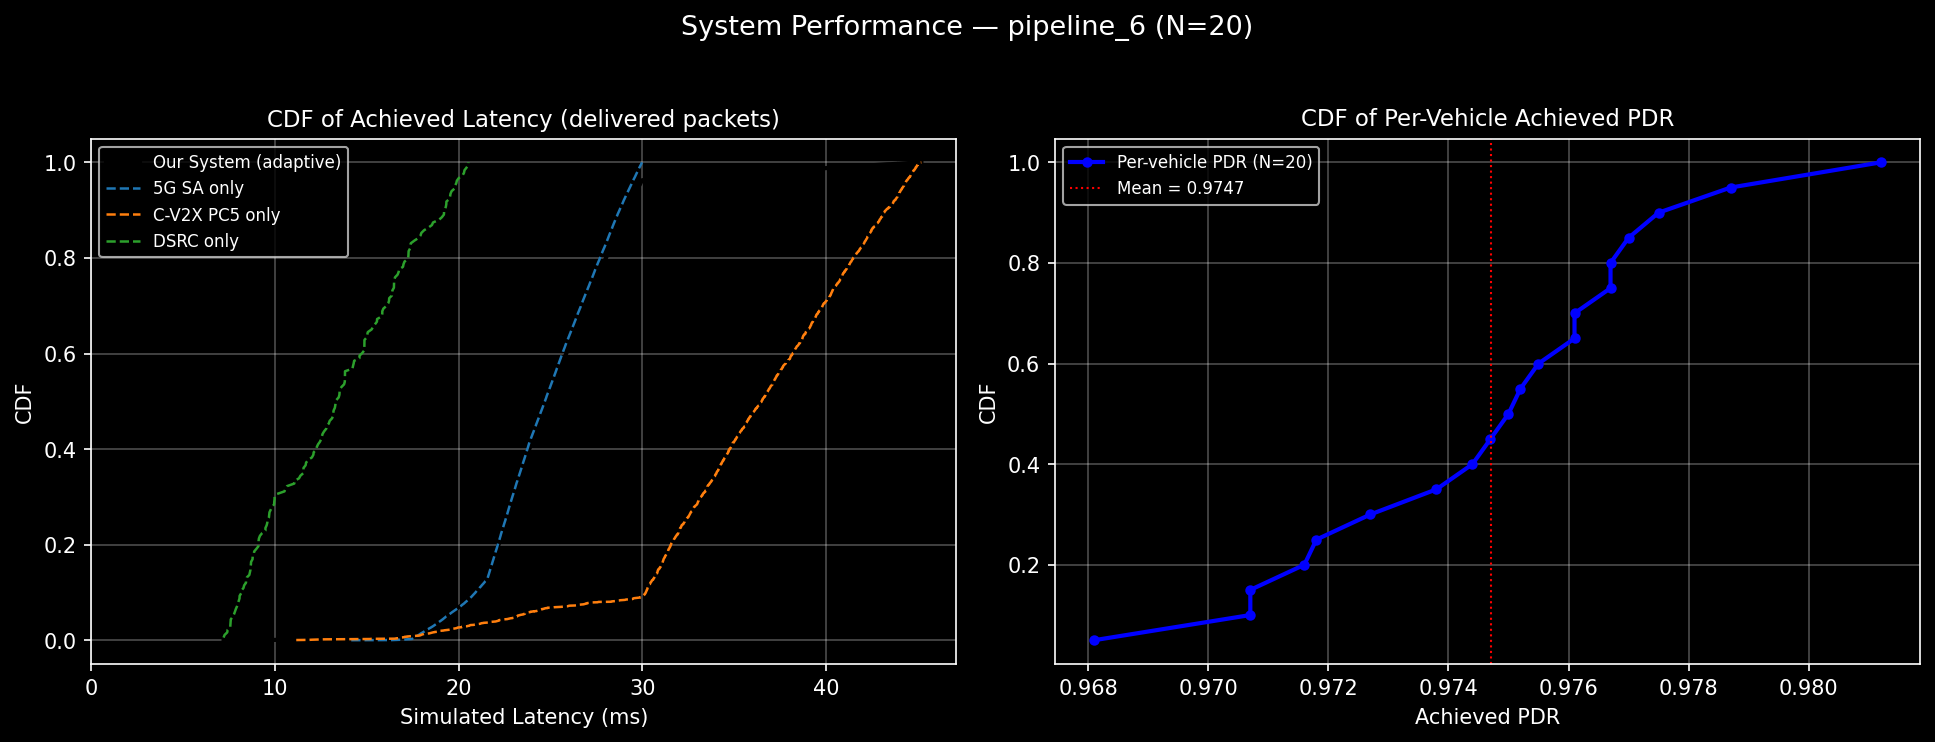

In [18]:
# ── Figure 2: CDF of Achieved Latency & PDR — System vs Single-RAT Baselines ──
# From feedback_multi_log: compare our selection vs always-5G / always-PC5 / always-DSRC

log = pd.read_csv(OUT / LATEST / "feedback_multi_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# -- Latency CDF --
# Our system: sim_latency for delivered packets
delivered = log[log["delivered"] == True]
sorted_lat = np.sort(delivered["sim_latency"].values)
cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
ax1.plot(sorted_lat, cdf, "k-", lw=2, label="Our System (adaptive)")

# Baselines: filter by RAT, use sim_latency for delivered only
for rat_key, rat_label in RAT_LABELS.items():
    mask = (log["selected_rat"] == rat_key) & (log["delivered"] == True)
    if mask.sum() == 0:
        continue
    vals = np.sort(log.loc[mask, "sim_latency"].values)
    c = np.arange(1, len(vals) + 1) / len(vals)
    ax1.plot(vals, c, color=RAT_COLORS[rat_key], lw=1.2, ls="--", label=f"{rat_label} only")

ax1.set_xlabel("Simulated Latency (ms)")
ax1.set_ylabel("CDF")
ax1.set_title("CDF of Achieved Latency (delivered packets)")
ax1.legend()
ax1.set_xlim(0, ax1.get_xlim()[1])
ax1.grid(True, alpha=0.3)

# -- PDR CDF (per-vehicle achieved PDR) --
pv = pd.read_csv(OUT / LATEST / "feedback_multi_per_vehicle.csv")
sorted_pdr = np.sort(pv["achieved_pdr"].values)
cdf_pdr = np.arange(1, len(sorted_pdr) + 1) / len(sorted_pdr)
ax2.plot(sorted_pdr, cdf_pdr, "bo-", lw=2, ms=4, label=f"Per-vehicle PDR (N={len(pv)})")
ax2.axvline(pv["achieved_pdr"].mean(), color="red", ls=":", lw=1, label=f"Mean = {pv['achieved_pdr'].mean():.4f}")
ax2.set_xlabel("Achieved PDR")
ax2.set_ylabel("CDF")
ax2.set_title("CDF of Per-Vehicle Achieved PDR")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(f"System Performance — {LATEST} (N={PIPELINES[LATEST]['n']})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG / "fig2_cdf_latency_pdr.png")
plt.show()


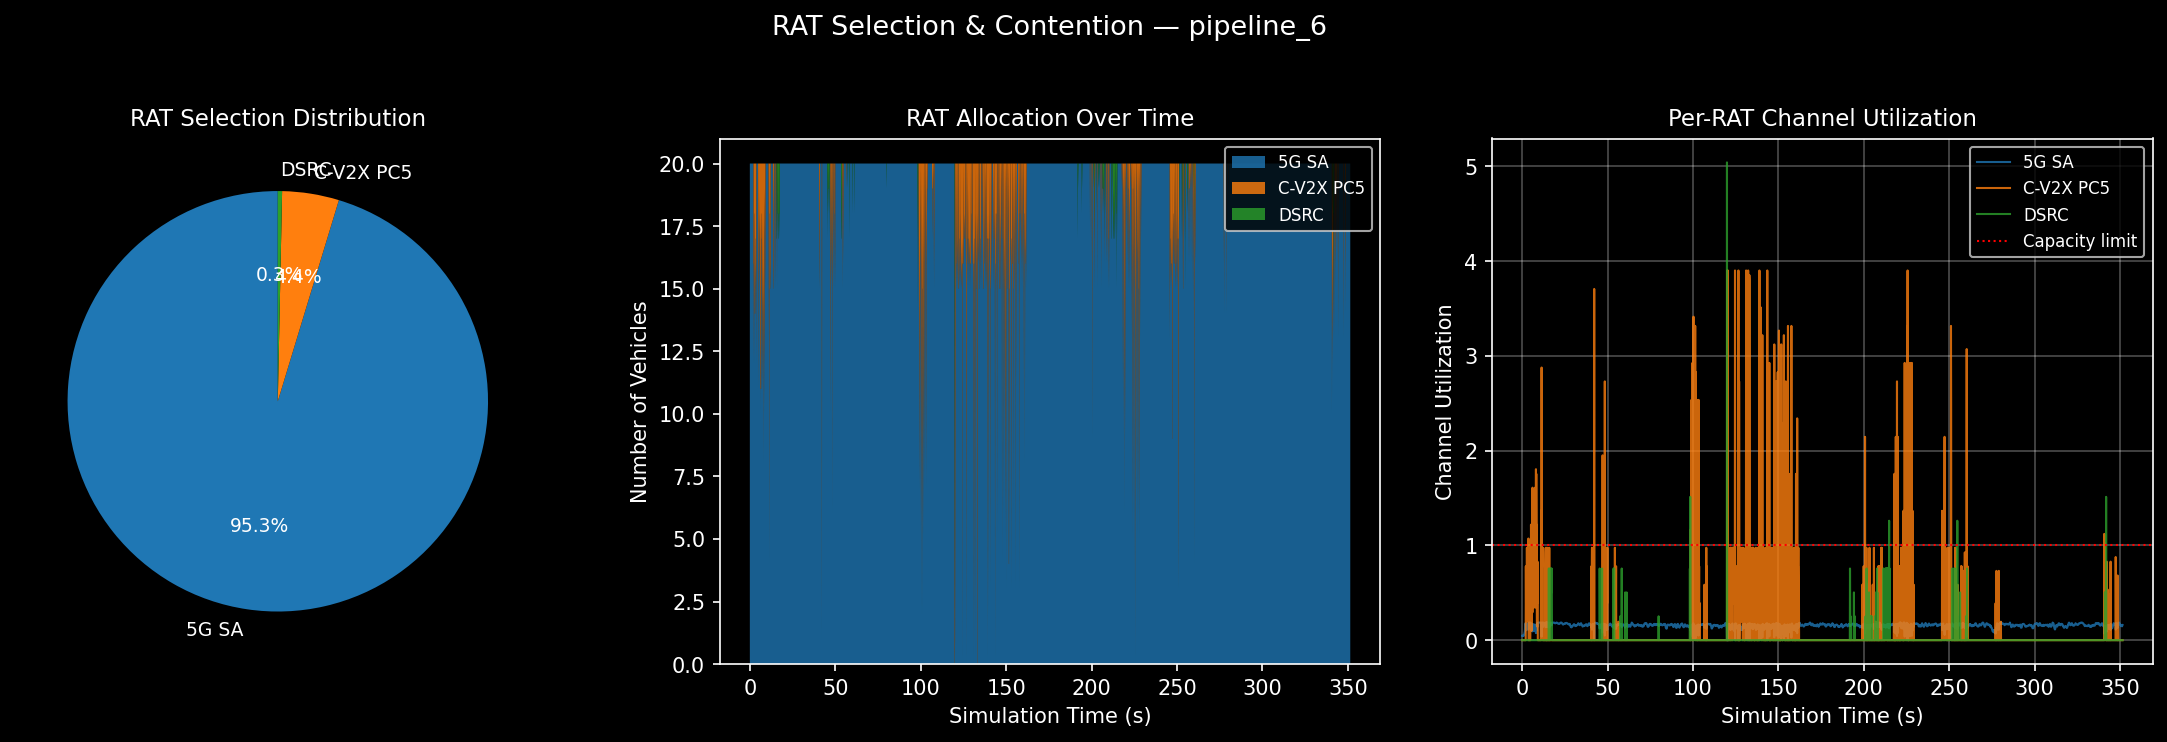

In [8]:
# ── Figure 3: RAT Selection Distribution + Contention Over Time ──

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 3a — RAT selection pie chart
rat_counts = log["selected_rat"].value_counts()
colors = [RAT_COLORS.get(r, "gray") for r in rat_counts.index]
labels = [RAT_LABELS.get(r, r) for r in rat_counts.index]
axes[0].pie(rat_counts.values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 9})
axes[0].set_title("RAT Selection Distribution")

# 3b — RAT selection over time (stacked area)
cont = pd.read_csv(OUT / LATEST / "feedback_multi_contention.csv")
t = cont["sim_time"]
axes[1].stackplot(t, cont["n_5g"], cont["n_pc5"], cont["n_dsrc"],
                  labels=["5G SA", "C-V2X PC5", "DSRC"],
                  colors=[RAT_COLORS["5g"], RAT_COLORS["pc5"], RAT_COLORS["dsrc"]],
                  alpha=0.8)
axes[1].set_xlabel("Simulation Time (s)")
axes[1].set_ylabel("Number of Vehicles")
axes[1].set_title("RAT Allocation Over Time")
axes[1].legend(loc="upper right", fontsize=8)

# 3c — Channel utilization over time
for rat_key in ["5g", "pc5", "dsrc"]:
    col = f"utilization_{rat_key}"
    if col in cont.columns:
        axes[2].plot(t, cont[col], color=RAT_COLORS[rat_key],
                     label=RAT_LABELS[rat_key], lw=1, alpha=0.8)
axes[2].axhline(1.0, color="red", ls=":", lw=1, label="Capacity limit")
axes[2].set_xlabel("Simulation Time (s)")
axes[2].set_ylabel("Channel Utilization")
axes[2].set_title("Per-RAT Channel Utilization")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"RAT Selection & Contention — {LATEST}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG / "fig3_rat_selection_contention.png")
plt.show()


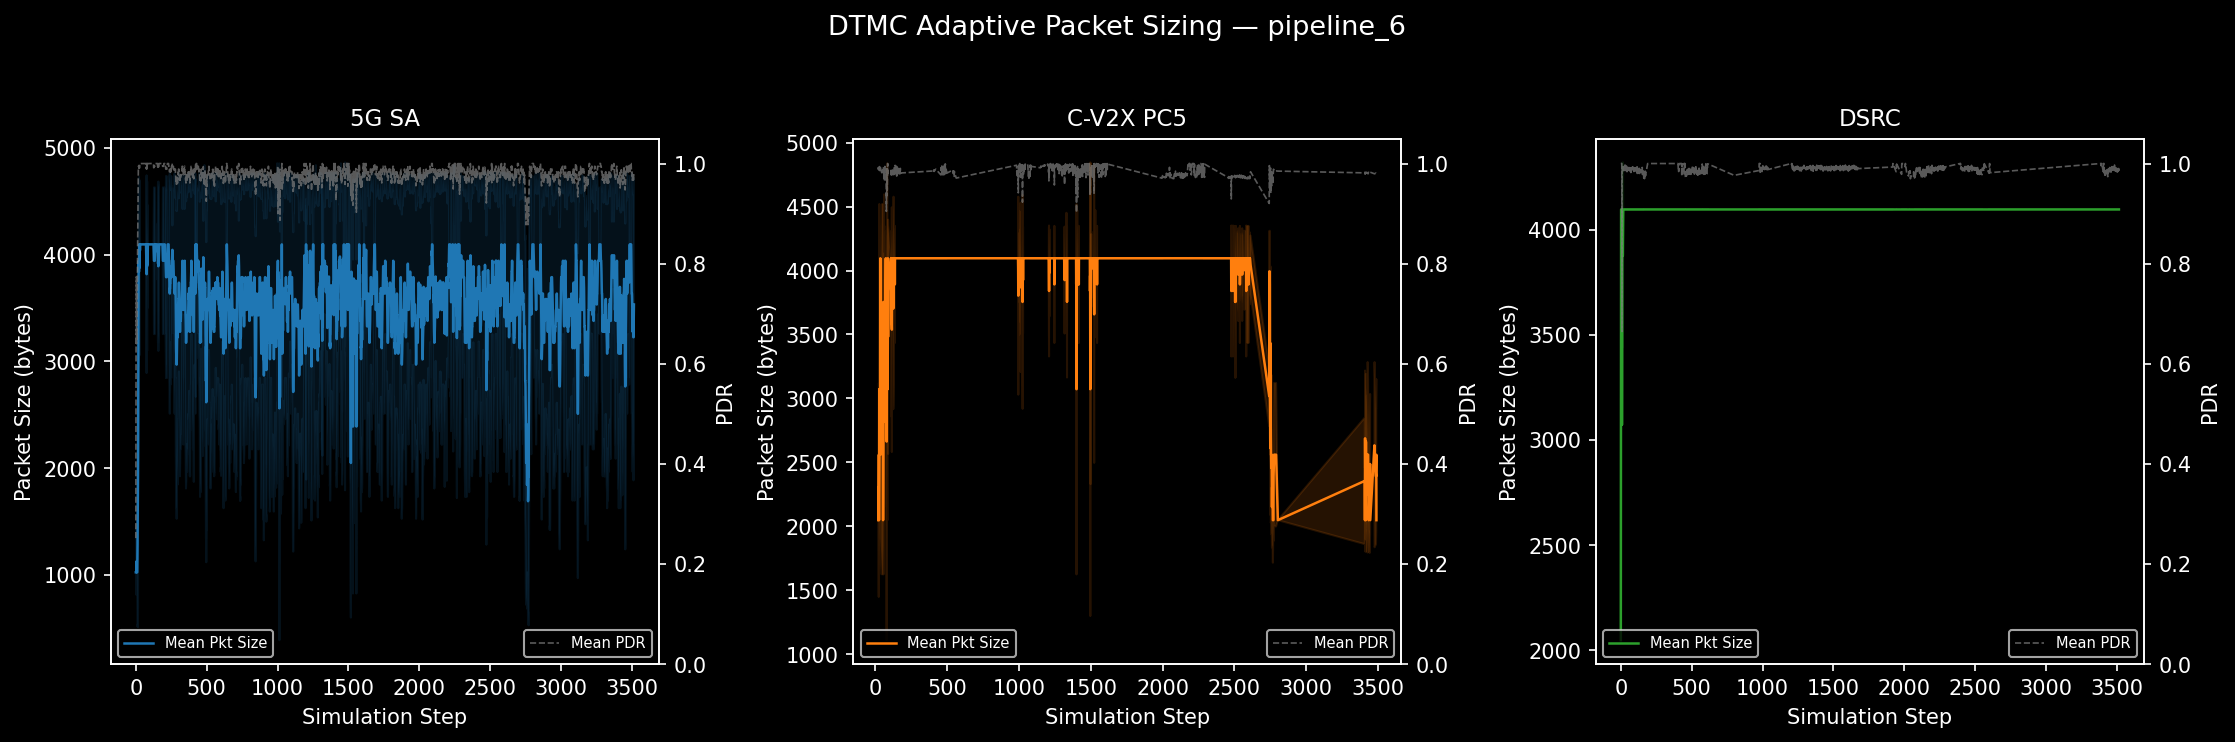

In [9]:
# ── Figure 4: DTMC Packet Size Adaptation ──

dtmc = pd.read_csv(OUT / LATEST / "feedback_multi_dtmc_transitions.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, rat_key in enumerate(["5g", "pc5", "dsrc"]):
    ax = axes[i]
    sub = dtmc[dtmc["rat"] == rat_key]

    if len(sub) == 0:
        ax.set_title(f"{RAT_LABELS[rat_key]} — No DTMC data")
        continue

    # Aggregate: mean packet size per step across vehicles
    agg = sub.groupby("step").agg(
        mean_size=("packet_size", "mean"),
        mean_pdr=("pdr", "mean"),
        std_size=("packet_size", "std"),
    ).reset_index()

    ax2 = ax.twinx()
    ax.plot(agg["step"], agg["mean_size"], color=RAT_COLORS[rat_key], lw=1.2, label="Mean Pkt Size")
    ax.fill_between(agg["step"],
                     agg["mean_size"] - agg["std_size"],
                     agg["mean_size"] + agg["std_size"],
                     color=RAT_COLORS[rat_key], alpha=0.15)
    ax2.plot(agg["step"], agg["mean_pdr"], color="gray", lw=0.8, ls="--", alpha=0.7, label="Mean PDR")

    ax.set_xlabel("Simulation Step")
    ax.set_ylabel("Packet Size (bytes)")
    ax2.set_ylabel("PDR")
    ax2.set_ylim(0, 1.05)
    ax.set_title(f"{RAT_LABELS[rat_key]}")
    ax.legend(loc="lower left", fontsize=7)
    ax2.legend(loc="lower right", fontsize=7)

fig.suptitle(f"DTMC Adaptive Packet Sizing — {LATEST}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG / "fig4_dtmc_adaptation.png")
plt.show()


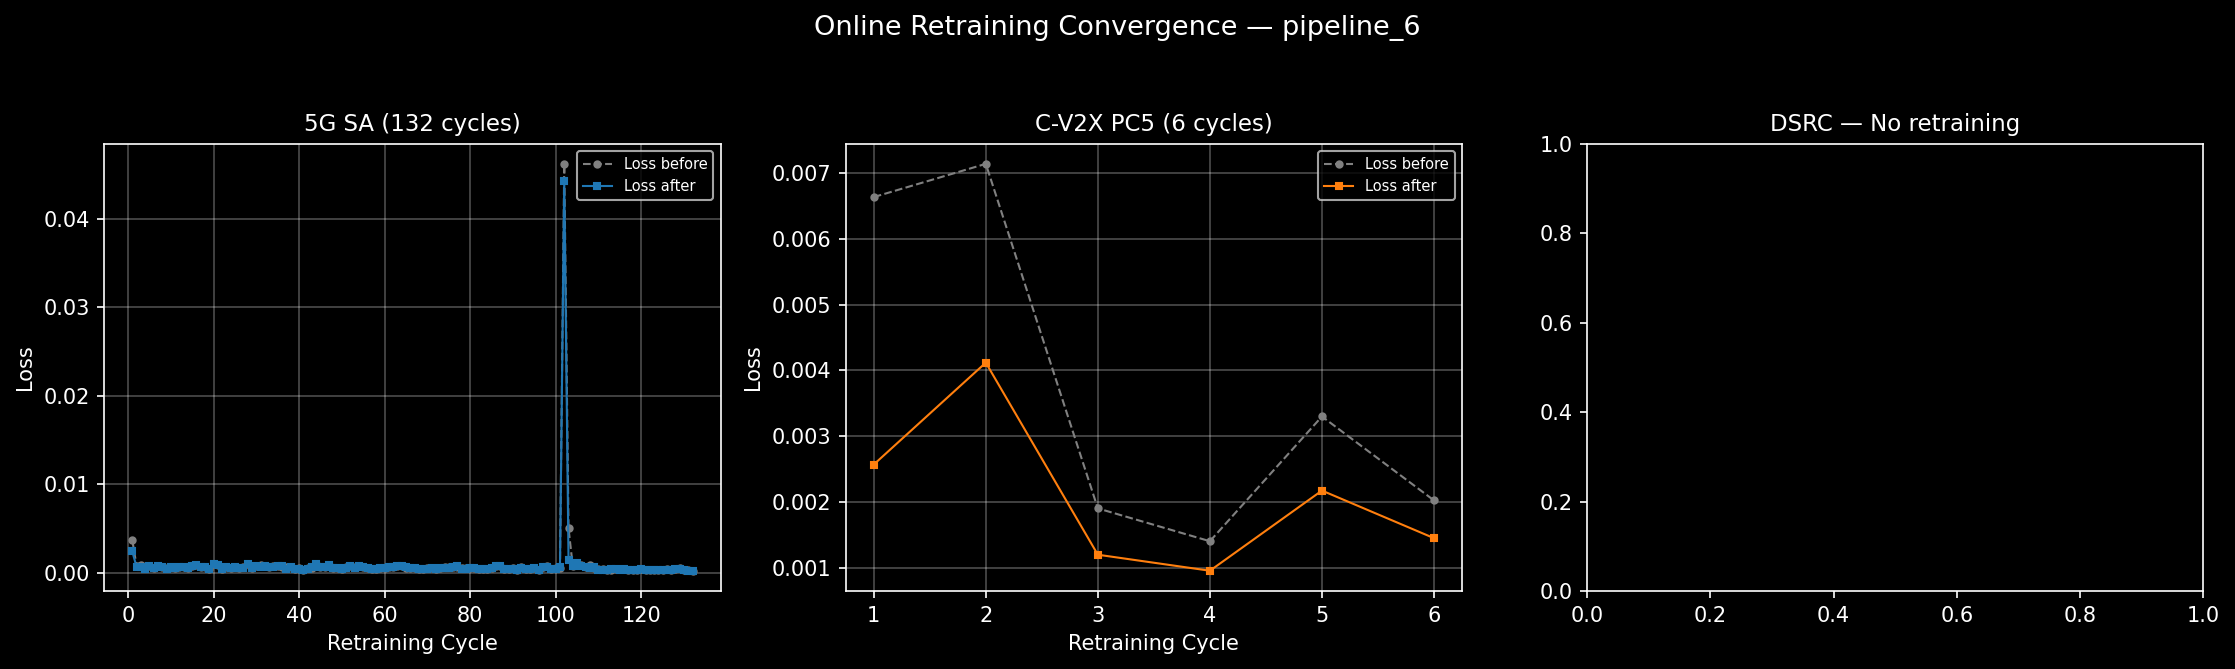

In [10]:
# ── Figure 5: Retraining Convergence — Loss Over Feedback Cycles ──

retrain = pd.read_csv(OUT / LATEST / "feedback_multi_retraining_log.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, rat_key in enumerate(["5g", "pc5", "dsrc"]):
    ax = axes[i]
    sub = retrain[retrain["rat"] == rat_key].copy()
    if len(sub) == 0:
        ax.set_title(f"{RAT_LABELS[rat_key]} — No retraining")
        continue

    ax.plot(sub["cycle"], sub["loss_before"], "o--", ms=3, lw=1, color="gray", label="Loss before")
    ax.plot(sub["cycle"], sub["loss_after"], "s-", ms=3, lw=1, color=RAT_COLORS[rat_key], label="Loss after")

    # Mark rollbacks
    rollbacks = sub[sub["rolled_back"] == True]
    if len(rollbacks) > 0:
        ax.scatter(rollbacks["cycle"], rollbacks["loss_after"], marker="x",
                   s=60, color="red", zorder=5, label=f"Rolled back ({len(rollbacks)})")

    ax.set_xlabel("Retraining Cycle")
    ax.set_ylabel("Loss")
    ax.set_title(f"{RAT_LABELS[rat_key]} ({len(sub)} cycles)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Online Retraining Convergence — {LATEST}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG / "fig5_retraining_convergence.png")
plt.show()


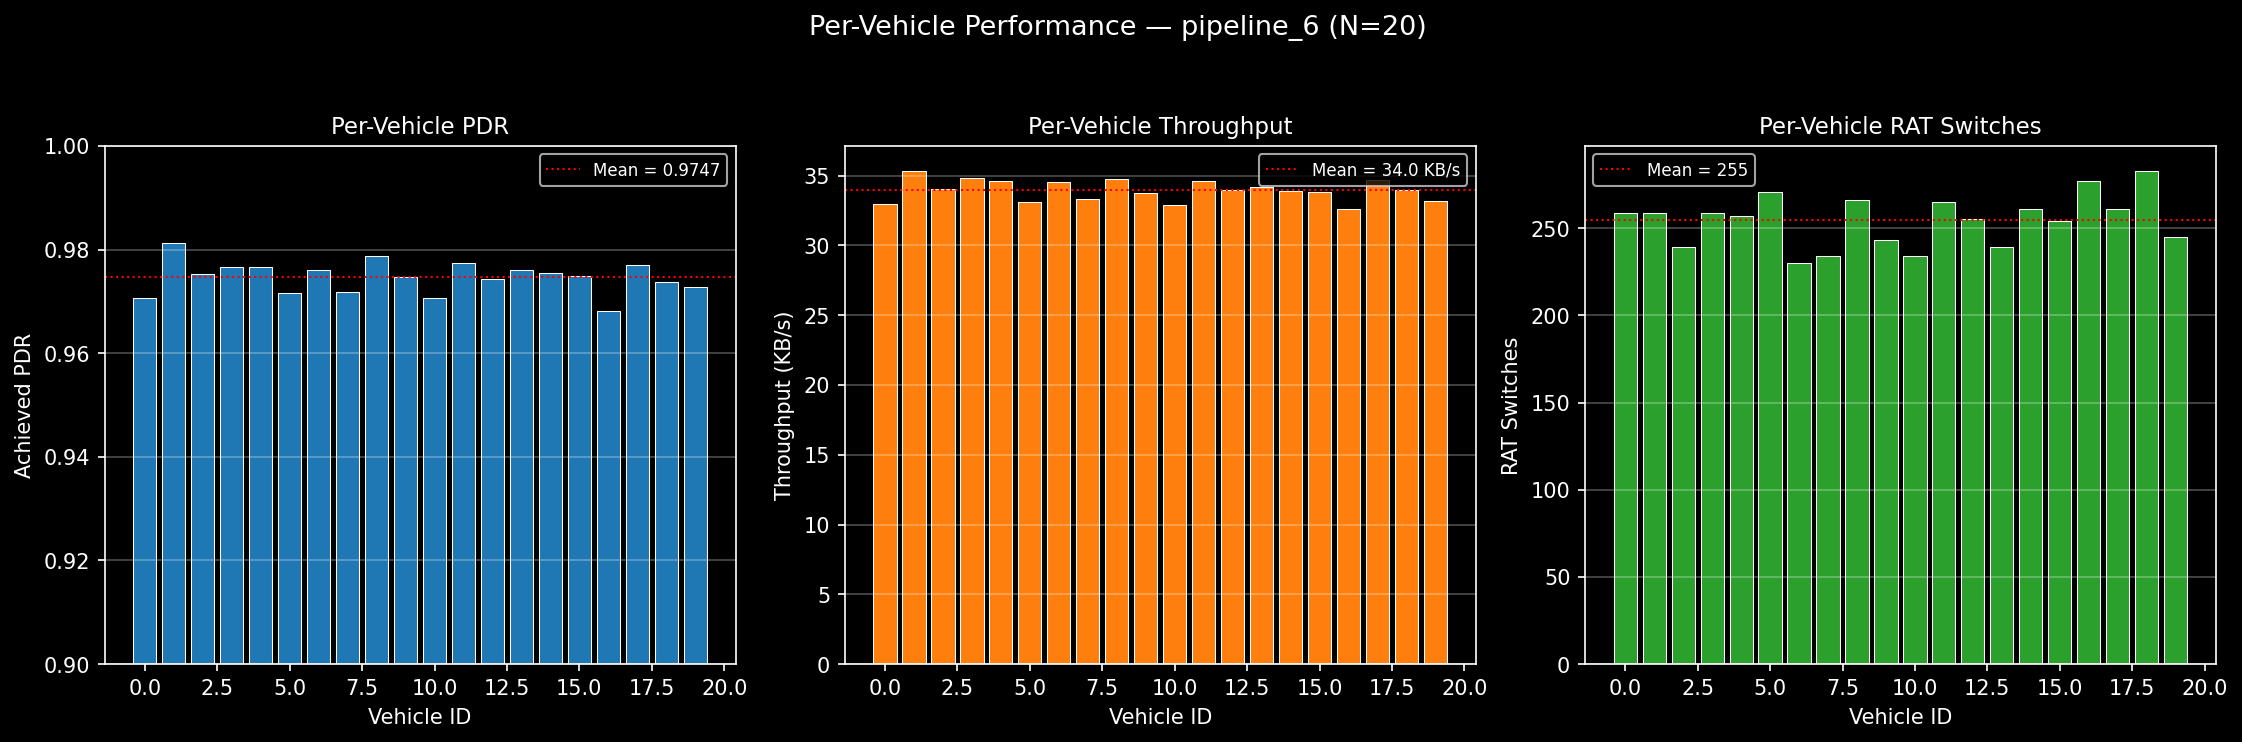

In [11]:
# ── Figure 6: Per-Vehicle Performance — PDR, Throughput, RAT Switches ──

pv = pd.read_csv(OUT / LATEST / "feedback_multi_per_vehicle.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 6a — Per-vehicle achieved PDR
axes[0].bar(pv["vehicle_id"], pv["achieved_pdr"], color="#1f77b4", edgecolor="white", lw=0.5)
axes[0].axhline(pv["achieved_pdr"].mean(), color="red", ls=":", lw=1,
                label=f"Mean = {pv['achieved_pdr'].mean():.4f}")
axes[0].set_xlabel("Vehicle ID")
axes[0].set_ylabel("Achieved PDR")
axes[0].set_title("Per-Vehicle PDR")
axes[0].set_ylim(0.9, 1.0)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# 6b — Per-vehicle throughput (KB/s)
tp_kbps = pv["throughput_bytes_per_s"] / 1024
axes[1].bar(pv["vehicle_id"], tp_kbps, color="#ff7f0e", edgecolor="white", lw=0.5)
axes[1].axhline(tp_kbps.mean(), color="red", ls=":", lw=1,
                label=f"Mean = {tp_kbps.mean():.1f} KB/s")
axes[1].set_xlabel("Vehicle ID")
axes[1].set_ylabel("Throughput (KB/s)")
axes[1].set_title("Per-Vehicle Throughput")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

# 6c — Per-vehicle RAT switches
axes[2].bar(pv["vehicle_id"], pv["rat_switches"], color="#2ca02c", edgecolor="white", lw=0.5)
axes[2].axhline(pv["rat_switches"].mean(), color="red", ls=":", lw=1,
                label=f"Mean = {pv['rat_switches'].mean():.0f}")
axes[2].set_xlabel("Vehicle ID")
axes[2].set_ylabel("RAT Switches")
axes[2].set_title("Per-Vehicle RAT Switches")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Per-Vehicle Performance — {LATEST} (N={len(pv)})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG / "fig6_per_vehicle_performance.png")
plt.show()


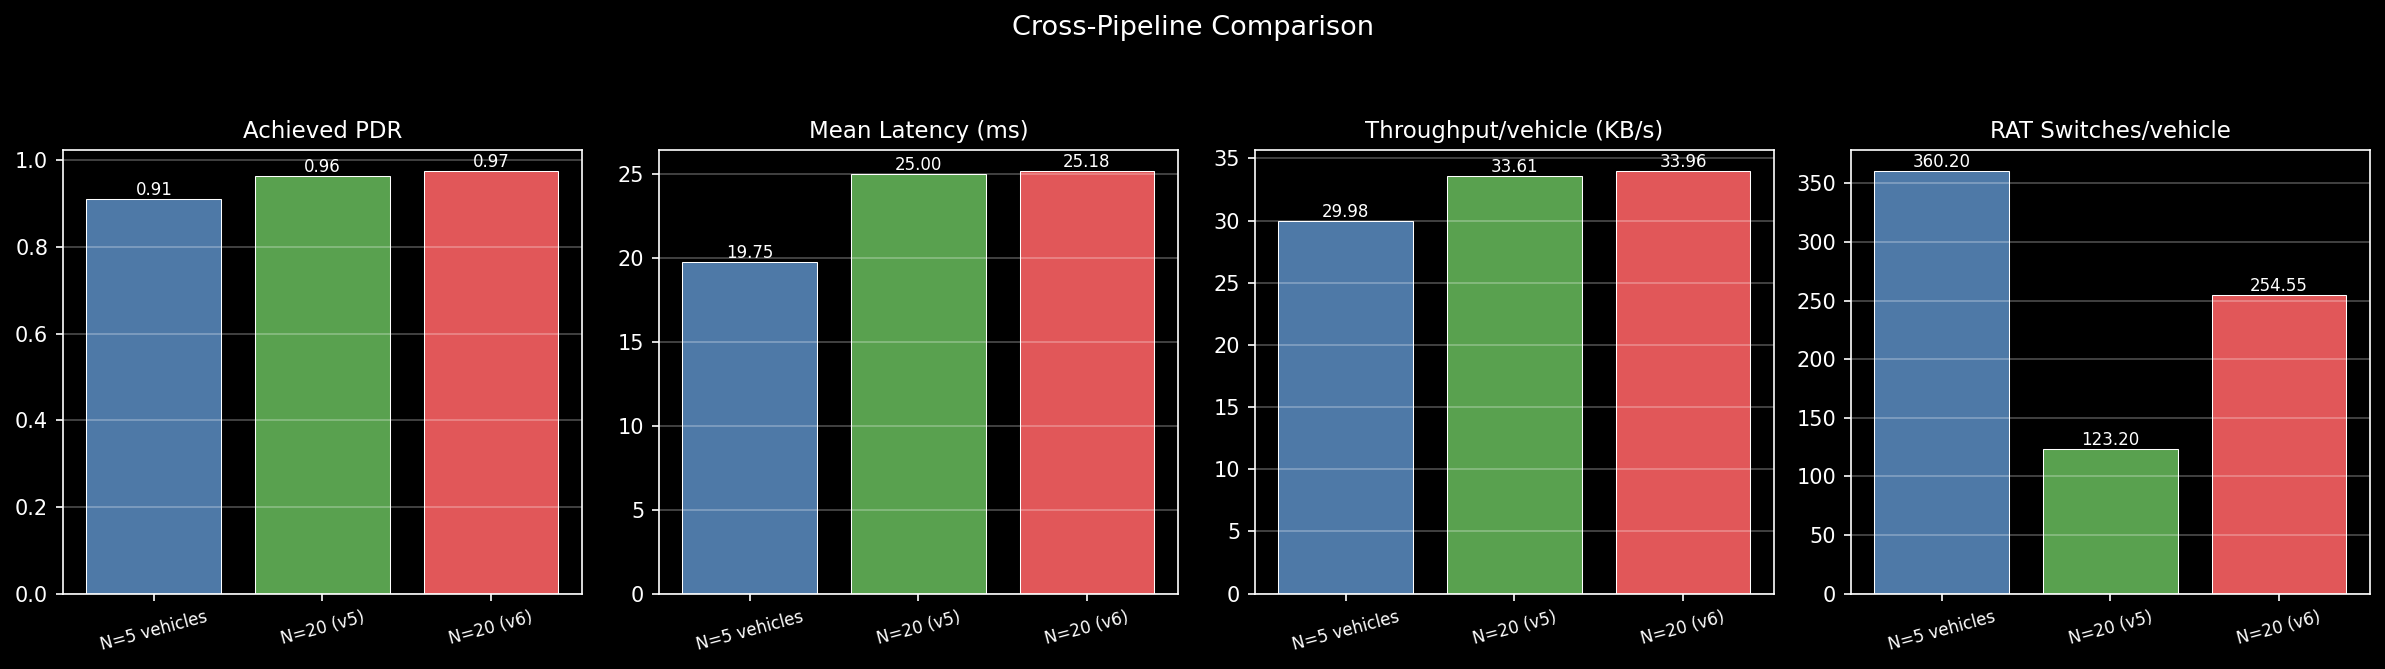


Full comparison table:
|                           |   N=5 vehicles |   N=20 (v5) |   N=20 (v6) |
|---------------------------|----------------|-------------|-------------|
| Achieved PDR              |         0.9100 |      0.9648 |      0.9747 |
| Mean Latency (ms)         |        19.7483 |     25.0050 |     25.1750 |
| Throughput/vehicle (KB/s) |        29.9778 |     33.6110 |     33.9579 |
| RAT Switches/vehicle      |       360.2000 |    123.2000 |    254.5500 |
| Retrain Cycles            |        34.0000 |    138.0000 |    138.0000 |
| 5G Pkt Size (B)           |      3672.3083 |   3568.1542 |   3554.0762 |
| PC5 Pkt Size (B)          |      2077.4725 |   4053.4331 |   3947.0081 |
| DSRC Pkt Size (B)         |      2514.5807 |   4090.1786 |   4090.8166 |


In [12]:
# ── Figure 7: Cross-Pipeline Comparison — Scalability (N=5 vs N=20) ──
# Compare pipeline_3 (5 vehicles) vs pipeline_6 (20 vehicles)

summaries = {}
for pname, pinfo in PIPELINES.items():
    fpath = OUT / pname / "feedback_multi_summary.csv"
    if fpath.exists():
        summaries[pname] = pd.read_csv(fpath).iloc[0]

comp_df = pd.DataFrame({
    pinfo["label"]: {
        "Achieved PDR": summaries[pname]["achieved_pdr"],
        "Mean Latency (ms)": summaries[pname]["mean_sim_latency"],
        "Throughput/vehicle (KB/s)": summaries[pname]["throughput_bytes_per_s"] / summaries[pname]["num_vehicles"] / 1024,
        "RAT Switches/vehicle": summaries[pname]["total_rat_switches"] / summaries[pname]["num_vehicles"],
        "Retrain Cycles": summaries[pname]["retrain_cycles_total"],
        "5G Pkt Size (B)": summaries[pname]["dtmc_5g_mean_packet_size"],
        "PC5 Pkt Size (B)": summaries[pname]["dtmc_pc5_mean_packet_size"],
        "DSRC Pkt Size (B)": summaries[pname]["dtmc_dsrc_mean_packet_size"],
    }
    for pname, pinfo in PIPELINES.items() if pname in summaries
})

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
metrics = ["Achieved PDR", "Mean Latency (ms)", "Throughput/vehicle (KB/s)", "RAT Switches/vehicle"]
colors_bar = ["#4e79a7", "#59a14f", "#e15759"]

for i, metric in enumerate(metrics):
    vals = comp_df.loc[metric]
    axes[i].bar(range(len(vals)), vals.values, color=colors_bar[:len(vals)],
                edgecolor="white", lw=0.5)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, fontsize=8, rotation=15)
    axes[i].set_title(metric)
    axes[i].grid(True, alpha=0.3, axis="y")
    for k, v in enumerate(vals.values):
        axes[i].text(k, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Cross-Pipeline Comparison", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG / "fig7_cross_pipeline_comparison.png")
plt.show()

print("\nFull comparison table:")
print(tabulate(comp_df, headers="keys", tablefmt="github", floatfmt=".4f"))


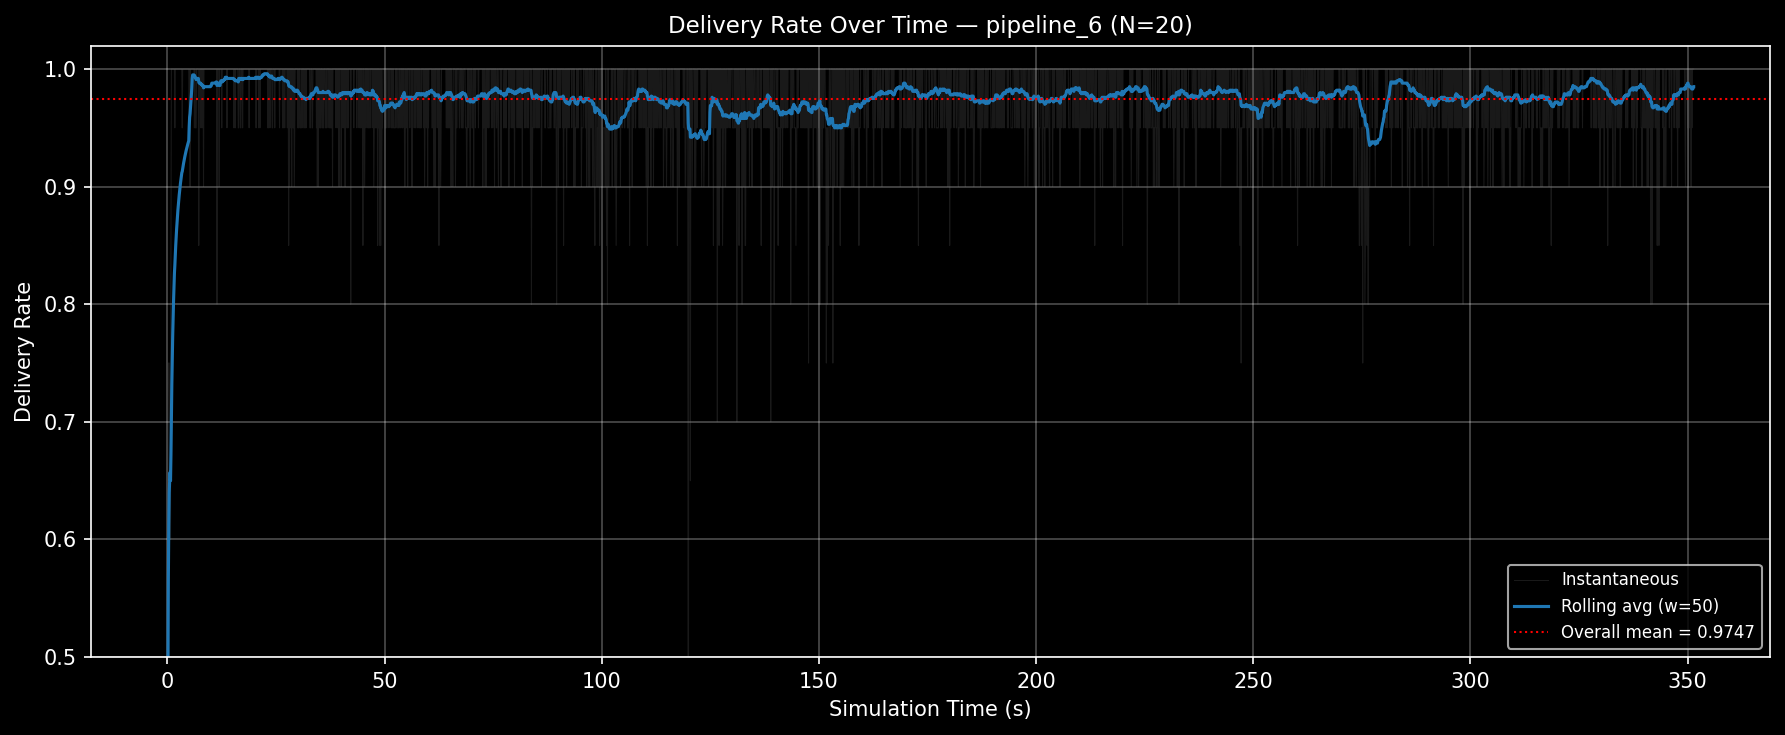

In [13]:
# ── Figure 8: Delivery Rate Over Time — Rolling Window ──
# Shows how PDR evolves during the simulation (1-second rolling window)

fig, ax = plt.subplots(figsize=(12, 5))

# Group by simulation time step, compute rolling delivery rate
time_groups = log.groupby("idx").agg(
    sim_time=("sim_time", "first"),
    delivered_count=("delivered", "sum"),
    total_count=("delivered", "count"),
).reset_index()
time_groups["delivery_rate"] = time_groups["delivered_count"] / time_groups["total_count"]

# Rolling average (window = 50 steps ~= 5 seconds at 0.1s intervals)
window = 50
time_groups["rolling_pdr"] = time_groups["delivery_rate"].rolling(window, min_periods=1).mean()

ax.plot(time_groups["sim_time"], time_groups["delivery_rate"],
        alpha=0.2, color="gray", lw=0.5, label="Instantaneous")
ax.plot(time_groups["sim_time"], time_groups["rolling_pdr"],
        color="#1f77b4", lw=1.5, label=f"Rolling avg (w={window})")
ax.axhline(pv["achieved_pdr"].mean(), color="red", ls=":", lw=1,
           label=f"Overall mean = {pv['achieved_pdr'].mean():.4f}")
ax.set_xlabel("Simulation Time (s)")
ax.set_ylabel("Delivery Rate")
ax.set_title(f"Delivery Rate Over Time — {LATEST} (N={PIPELINES[LATEST]['n']})")
ax.set_ylim(0.5, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "fig8_delivery_rate_over_time.png")
plt.show()


/tmp/ipykernel_19945/2038648847.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(lat_errors, labels=labels, patch_artist=True, showfliers=False,
/tmp/ipykernel_19945/2038648847.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(pdr_errors, labels=labels, patch_artist=True, showfliers=False,


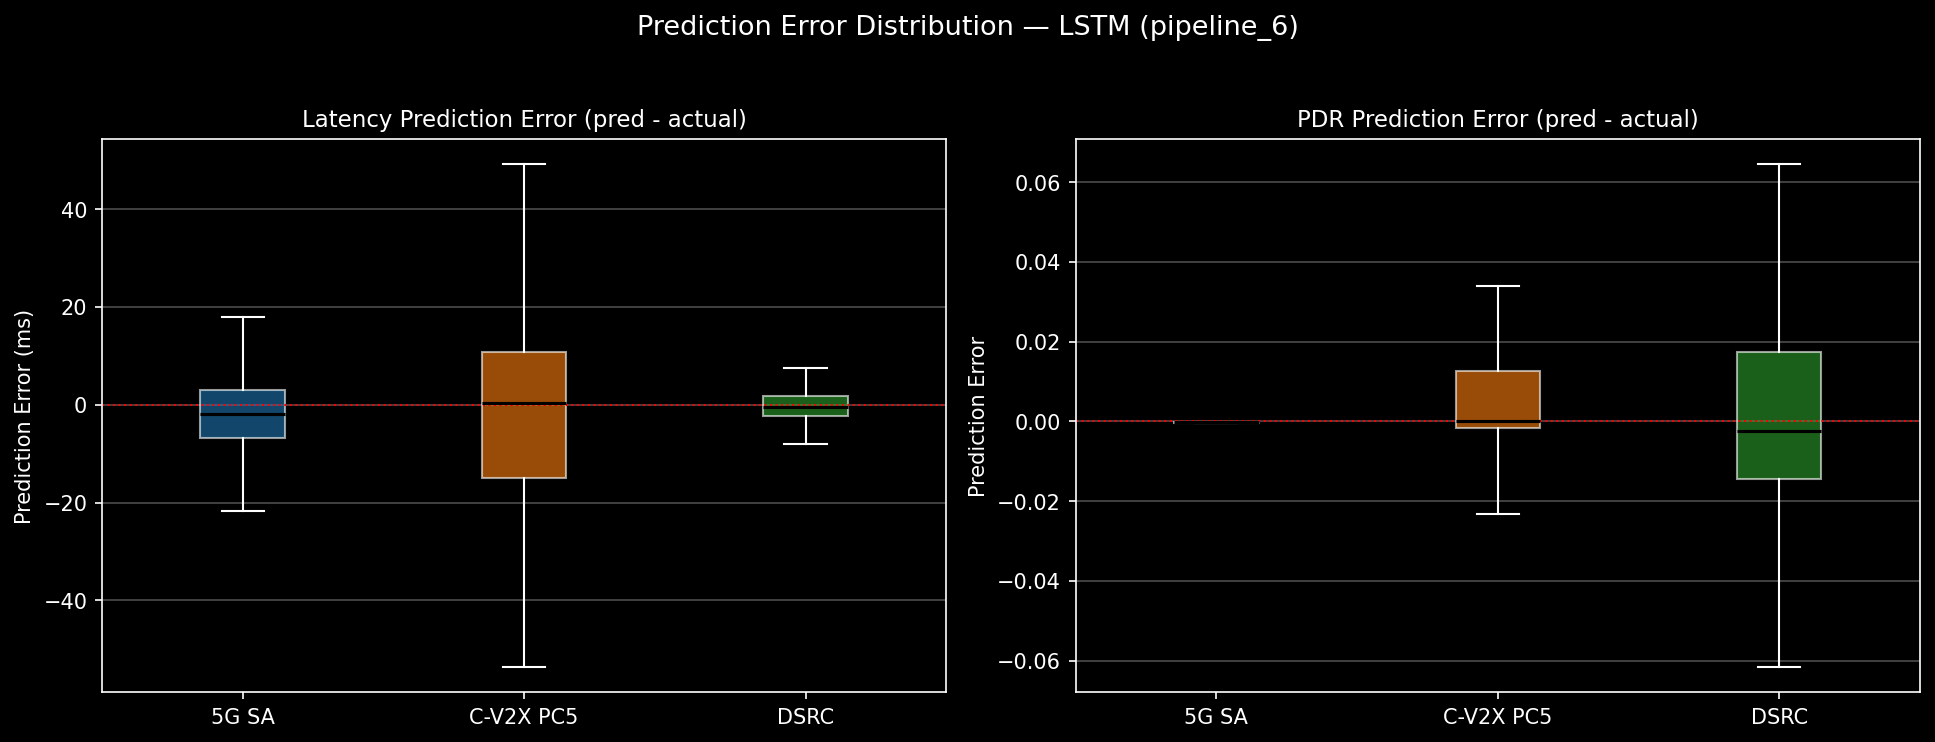

In [14]:
# ── Figure 9: Prediction Error Distribution — Box/Violin Plots ──

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lat_errors, pdr_errors, labels = [], [], []
for rat_key in ["5g", "pc5", "dsrc"]:
    flog = pd.read_csv(OUT / LATEST / f"final_log_lstm_{rat_key}.csv")
    lat_errors.append(flog["pred_latency"] - flog["actual_latency"])
    pdr_errors.append(flog["pred_pdr"] - flog["actual_pdr"])
    labels.append(RAT_LABELS[rat_key])

# Latency error distribution
bp1 = axes[0].boxplot(lat_errors, labels=labels, patch_artist=True, showfliers=False,
                       medianprops=dict(color="black", lw=1.5))
for patch, rat_key in zip(bp1["boxes"], ["5g", "pc5", "dsrc"]):
    patch.set_facecolor(RAT_COLORS[rat_key])
    patch.set_alpha(0.6)
axes[0].axhline(0, color="red", ls=":", lw=1)
axes[0].set_ylabel("Prediction Error (ms)")
axes[0].set_title("Latency Prediction Error (pred - actual)")
axes[0].grid(True, alpha=0.3, axis="y")

# PDR error distribution
bp2 = axes[1].boxplot(pdr_errors, labels=labels, patch_artist=True, showfliers=False,
                       medianprops=dict(color="black", lw=1.5))
for patch, rat_key in zip(bp2["boxes"], ["5g", "pc5", "dsrc"]):
    patch.set_facecolor(RAT_COLORS[rat_key])
    patch.set_alpha(0.6)
axes[1].axhline(0, color="red", ls=":", lw=1)
axes[1].set_ylabel("Prediction Error")
axes[1].set_title("PDR Prediction Error (pred - actual)")
axes[1].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Prediction Error Distribution — LSTM ({LATEST})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG / "fig9_prediction_error_distribution.png")
plt.show()


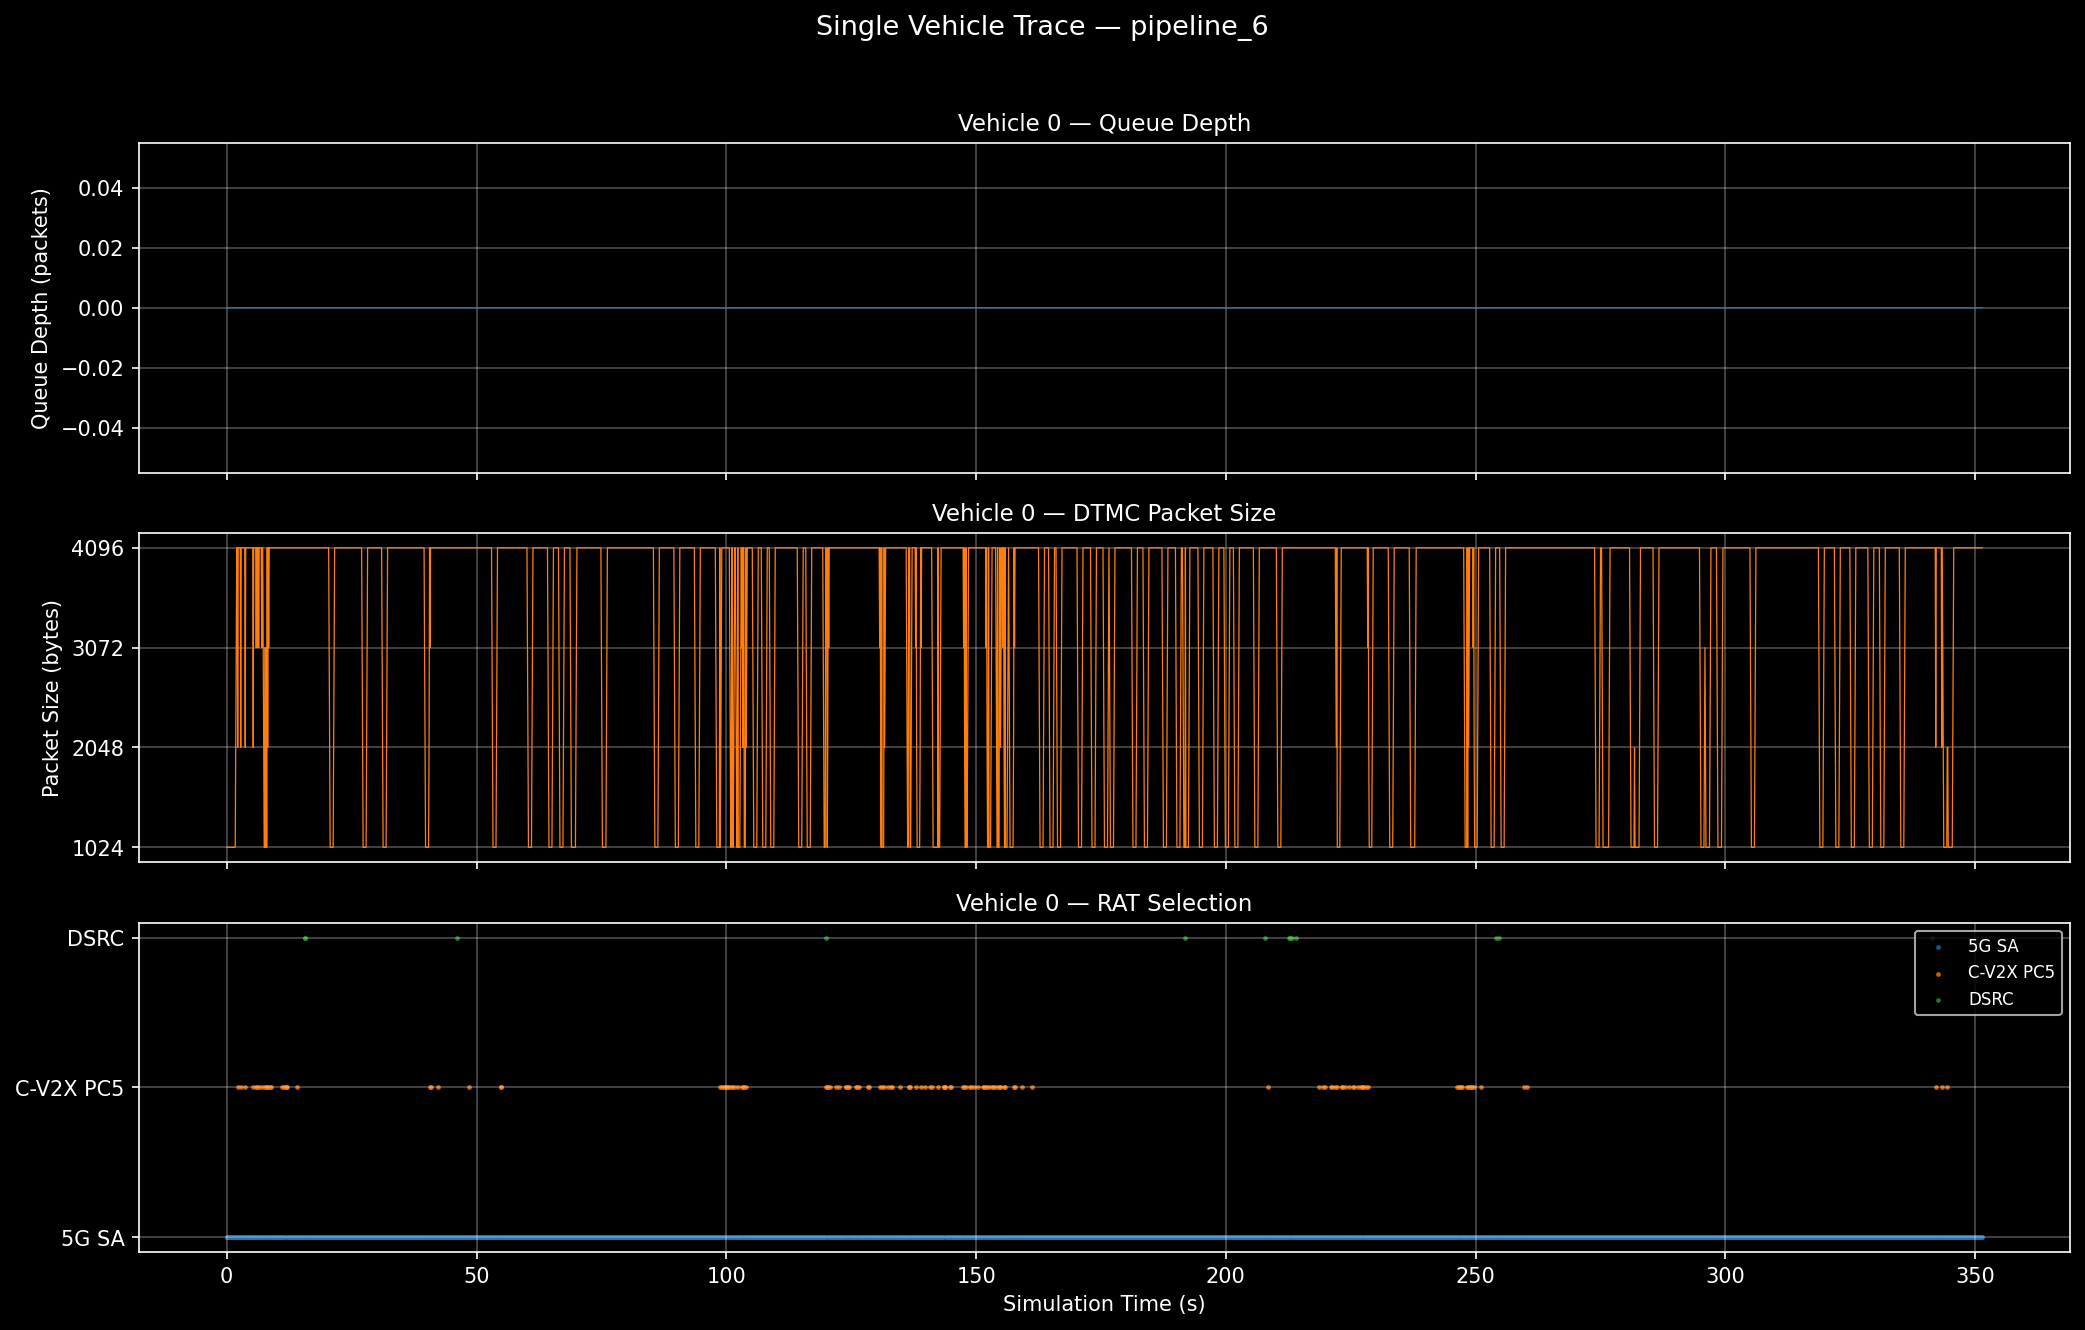

In [15]:
# ── Figure 10: Queue Depth & Packet Size Over Time (single vehicle trace) ──

v0 = log[log["vehicle_id"] == 0].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 10a — Queue depth over time
axes[0].plot(v0["sim_time"], v0["queue_depth"], lw=0.6, color="#1f77b4")
axes[0].set_ylabel("Queue Depth (packets)")
axes[0].set_title("Vehicle 0 — Queue Depth")
axes[0].grid(True, alpha=0.3)

# 10b — Packet size (DTMC state) over time
axes[1].plot(v0["sim_time"], v0["dtmc_size"], lw=0.6, color="#ff7f0e")
axes[1].set_ylabel("Packet Size (bytes)")
axes[1].set_title("Vehicle 0 — DTMC Packet Size")
axes[1].set_yticks([1024, 2048, 3072, 4096])
axes[1].grid(True, alpha=0.3)

# 10c — Selected RAT over time (color-coded)
rat_map = {"5g": 0, "pc5": 1, "dsrc": 2}
v0["rat_num"] = v0["selected_rat"].map(rat_map)
for rat_key, rat_num in rat_map.items():
    mask = v0["rat_num"] == rat_num
    axes[2].scatter(v0.loc[mask, "sim_time"], v0.loc[mask, "rat_num"],
                    s=2, color=RAT_COLORS[rat_key], label=RAT_LABELS[rat_key], alpha=0.6)
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(["5G SA", "C-V2X PC5", "DSRC"])
axes[2].set_xlabel("Simulation Time (s)")
axes[2].set_title("Vehicle 0 — RAT Selection")
axes[2].legend(fontsize=8, loc="upper right")
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Single Vehicle Trace — {LATEST}", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG / "fig10_single_vehicle_trace.png")
plt.show()


In [16]:
# ── Table 1: Summary Statistics — Latest Pipeline ──

summary = pd.read_csv(OUT / LATEST / "feedback_multi_summary.csv").iloc[0]

table_data = {
    "Metric": [
        "Total Packets", "Successful Packets", "Achieved PDR",
        "Mean Sim Latency (ms)", "Mean Pred Latency (ms)",
        "Throughput/vehicle (KB/s)", "RAT Switches/vehicle",
        "Retrain Cycles (total)", "Retrain 5G / PC5 / DSRC",
        "RAT Distribution: 5G", "RAT Distribution: PC5", "RAT Distribution: DSRC",
        "DTMC 5G Mean Pkt (B)", "DTMC PC5 Mean Pkt (B)", "DTMC DSRC Mean Pkt (B)",
    ],
    "Value": [
        f"{summary['total_packets']:,.0f}",
        f"{summary['successful_packets']:,.0f}",
        f"{summary['achieved_pdr']:.4f}",
        f"{summary['mean_sim_latency']:.2f}",
        f"{summary['mean_pred_latency']:.2f}",
        f"{summary['throughput_bytes_per_s'] / summary['num_vehicles'] / 1024:.1f}",
        f"{summary['total_rat_switches'] / summary['num_vehicles']:.1f}",
        f"{summary['retrain_cycles_total']:.0f}",
        f"{summary['retrain_5g']:.0f} / {summary['retrain_pc5']:.0f} / {summary['retrain_dsrc']:.0f}",
        f"{summary['rat_5g']:,.0f} ({summary['rat_5g']/summary['total_packets']*100:.1f}%)",
        f"{summary['rat_pc5']:,.0f} ({summary['rat_pc5']/summary['total_packets']*100:.1f}%)",
        f"{summary['rat_dsrc']:,.0f} ({summary['rat_dsrc']/summary['total_packets']*100:.1f}%)",
        f"{summary['dtmc_5g_mean_packet_size']:.0f}",
        f"{summary['dtmc_pc5_mean_packet_size']:.0f}",
        f"{summary['dtmc_dsrc_mean_packet_size']:.0f}",
    ],
}

print(f"=== {LATEST} Summary (N={summary['num_vehicles']:.0f}, seed={summary['seed']:.0f}) ===\n")
print(tabulate(pd.DataFrame(table_data), headers="keys", tablefmt="github", showindex=False))


=== pipeline_6 Summary (N=20, seed=42) ===

| Metric                    | Value          |
|---------------------------|----------------|
| Total Packets             | 70,300         |
| Successful Packets        | 68,522         |
| Achieved PDR              | 0.9747         |
| Mean Sim Latency (ms)     | 25.18          |
| Mean Pred Latency (ms)    | 34.59          |
| Throughput/vehicle (KB/s) | 34.0           |
| RAT Switches/vehicle      | 254.6          |
| Retrain Cycles (total)    | 138            |
| Retrain 5G / PC5 / DSRC   | 132 / 6 / 0    |
| RAT Distribution: 5G      | 67,001 (95.3%) |
| RAT Distribution: PC5     | 3,069 (4.4%)   |
| RAT Distribution: DSRC    | 230 (0.3%)     |
| DTMC 5G Mean Pkt (B)      | 3554           |
| DTMC PC5 Mean Pkt (B)     | 3947           |
| DTMC DSRC Mean Pkt (B)    | 4091           |


In [17]:
# ── Table 2: Prediction Accuracy Summary Per RAT ──

rows = []
for rat_key in ["5g", "pc5", "dsrc"]:
    flog = pd.read_csv(OUT / LATEST / f"final_log_lstm_{rat_key}.csv")
    r_lat, _ = stats.pearsonr(flog["actual_latency"], flog["pred_latency"])
    r_pdr, _ = stats.pearsonr(flog["actual_pdr"], flog["pred_pdr"])
    rows.append({
        "RAT": RAT_LABELS[rat_key],
        "N samples": len(flog),
        "Latency MAE (ms)": f"{flog['mae_latency'].mean():.2f}",
        "Latency RMSE (ms)": f"{flog['rmse_latency'].iloc[0]:.2f}",
        "Latency r": f"{r_lat:.3f}",
        "PDR MAE": f"{flog['mae_pdr'].mean():.4f}",
        "PDR RMSE": f"{flog['rmse_pdr'].iloc[0]:.4f}",
        "PDR r": f"{r_pdr:.3f}",
    })

acc_df = pd.DataFrame(rows)
print(f"=== Prediction Accuracy — LSTM ({LATEST}) ===\n")
print(tabulate(acc_df, headers="keys", tablefmt="github", showindex=False))


=== Prediction Accuracy — LSTM (pipeline_6) ===

| RAT       |   N samples |   Latency MAE (ms) |   Latency RMSE (ms) |   Latency r |   PDR MAE |   PDR RMSE |   PDR r |
|-----------|-------------|--------------------|---------------------|-------------|-----------|------------|---------|
| 5G SA     |        2980 |               6.54 |               15.62 |       0.013 |    0.001  |     0.0002 |  -0.001 |
| C-V2X PC5 |        2368 |              18.43 |               38.6  |       0.532 |    0.0349 |     0.1607 |   0.973 |
| DSRC      |        2065 |               2.66 |               17.55 |       0.037 |    0.0375 |     0.2334 |   0.954 |


In [20]:
# =============================================================================
# Multi-Vehicle Scalability Analysis
# =============================================================================
# Data from output/lstm_multi_vehicle/ batch runs

MV_DIR = OUT / "lstm_multi_vehicle"

# Auto-discover runs and extract vehicle count + summaries
mv_runs = {}
for run_dir in sorted(MV_DIR.glob("run_*")):
    # Extract vehicle count from directory name (e.g., run_..._lstm_5v -> 5)
    name = run_dir.name
    nv_str = name.rsplit("_", 1)[-1]  # e.g. "5v"
    nv = int(nv_str.replace("v", ""))

    # Multi-vehicle summary (N>=2)
    multi_summary = run_dir / "feedback_multi_summary.csv"
    single_summary = run_dir / "feedback_loop_summary.csv"
    baseline_summary = run_dir / "feedback_multi_baseline_summary.csv"

    entry = {"dir": run_dir, "n": nv}

    if multi_summary.exists():
        s = pd.read_csv(multi_summary).iloc[0]
        entry["summary"] = s
        entry["pdr"] = s["achieved_pdr"]
        entry["latency"] = s["mean_sim_latency"]
        entry["tp_per_v"] = s["throughput_bytes_per_s"] / s["num_vehicles"] / 1024
        entry["switches_per_v"] = s["total_rat_switches"] / s["num_vehicles"]
        entry["rat_5g_pct"] = s["rat_5g"] / s["total_packets"] * 100
        entry["rat_pc5_pct"] = s["rat_pc5"] / s["total_packets"] * 100
        entry["rat_dsrc_pct"] = s["rat_dsrc"] / s["total_packets"] * 100
        entry["dtmc_5g"] = s["dtmc_5g_mean_packet_size"]
        entry["dtmc_pc5"] = s["dtmc_pc5_mean_packet_size"]
        entry["dtmc_dsrc"] = s["dtmc_dsrc_mean_packet_size"]
    elif single_summary.exists():
        s = pd.read_csv(single_summary).iloc[0]
        entry["summary"] = s
        entry["pdr"] = s["achieved_pdr"]
        entry["latency"] = s["mean_sim_latency"]
        entry["tp_per_v"] = s["throughput_bytes_per_s"] / 1024  # single vehicle
        entry["switches_per_v"] = s["rat_switches"]
        total = s["rat_5g"] + s["rat_pc5"] + s["rat_dsrc"]
        entry["rat_5g_pct"] = s["rat_5g"] / total * 100
        entry["rat_pc5_pct"] = s["rat_pc5"] / total * 100
        entry["rat_dsrc_pct"] = s["rat_dsrc"] / total * 100
        entry["dtmc_5g"] = s["dtmc_5g_mean_packet_size"]
        entry["dtmc_pc5"] = s["dtmc_pc5_mean_packet_size"]
        entry["dtmc_dsrc"] = s["dtmc_dsrc_mean_packet_size"]

    if baseline_summary.exists():
        bs = pd.read_csv(baseline_summary).iloc[0]
        entry["baseline"] = bs
        entry["bl_pdr"] = bs["achieved_pdr"]
        entry["bl_latency"] = bs["mean_sim_latency"]
        entry["bl_tp_per_v"] = bs["throughput_bytes_per_s"] / bs["num_vehicles"] / 1024

    mv_runs[nv] = entry

nv_list = sorted(mv_runs.keys())
print(f"Discovered {len(nv_list)} vehicle counts: {nv_list}")
for nv in nv_list:
    e = mv_runs[nv]
    bl = f", baseline PDR={e['bl_pdr']:.4f}" if "bl_pdr" in e else ""
    print(f"  N={nv:>3d}: PDR={e['pdr']:.4f}, lat={e['latency']:.1f}ms, tp/v={e['tp_per_v']:.1f} KB/s{bl}")


Discovered 5 vehicle counts: [1, 2, 5, 10, 20]
  N=  1: PDR=0.9987, lat=19.6ms, tp/v=199.5 KB/s
  N=  2: PDR=0.9840, lat=22.6ms, tp/v=174.2 KB/s, baseline PDR=0.9874
  N=  5: PDR=0.9737, lat=20.6ms, tp/v=154.3 KB/s, baseline PDR=0.9842
  N= 10: PDR=0.9770, lat=22.2ms, tp/v=164.5 KB/s, baseline PDR=0.9819
  N= 20: PDR=0.9743, lat=24.4ms, tp/v=159.8 KB/s, baseline PDR=0.9800


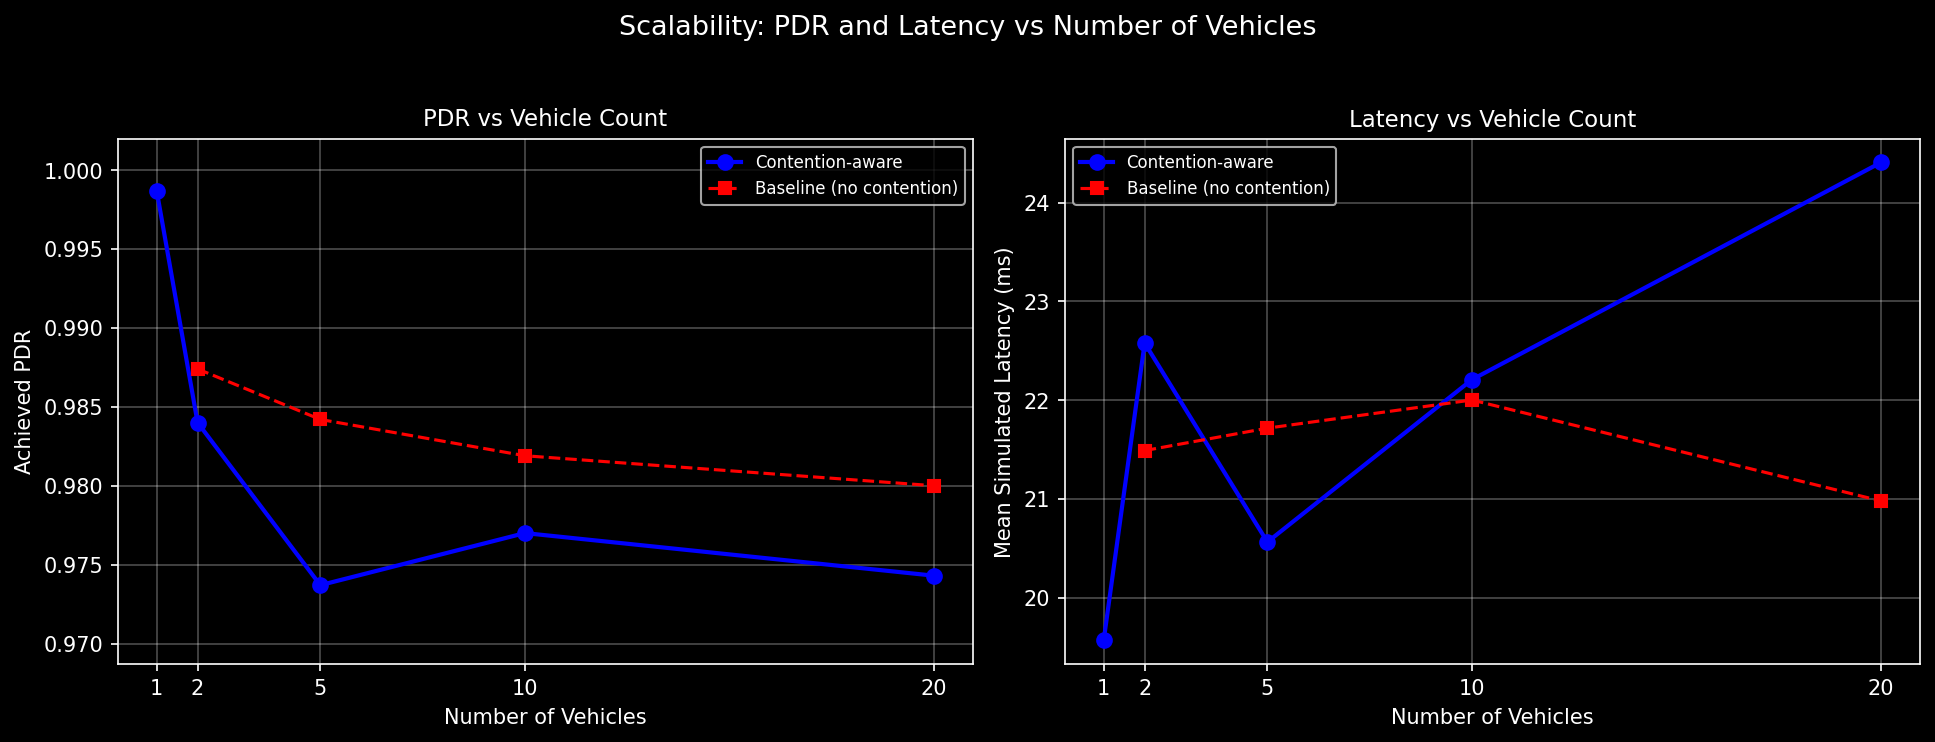

In [21]:
# ── Figure 11: Scalability — PDR & Latency vs Number of Vehicles ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

nv_arr = np.array(nv_list)
pdr_arr = np.array([mv_runs[n]["pdr"] for n in nv_list])
lat_arr = np.array([mv_runs[n]["latency"] for n in nv_list])

# Baseline arrays (only where available)
nv_bl = [n for n in nv_list if "bl_pdr" in mv_runs[n]]
pdr_bl = [mv_runs[n]["bl_pdr"] for n in nv_bl]
lat_bl = [mv_runs[n]["bl_latency"] for n in nv_bl]

# PDR vs N
ax1.plot(nv_arr, pdr_arr, "bo-", lw=2, ms=7, label="Contention-aware")
if nv_bl:
    ax1.plot(nv_bl, pdr_bl, "rs--", lw=1.5, ms=6, label="Baseline (no contention)")
ax1.set_xlabel("Number of Vehicles")
ax1.set_ylabel("Achieved PDR")
ax1.set_title("PDR vs Vehicle Count")
ax1.set_xticks(nv_arr)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(min(pdr_arr.min(), min(pdr_bl) if pdr_bl else 1) - 0.005, 1.002)

# Latency vs N
ax2.plot(nv_arr, lat_arr, "bo-", lw=2, ms=7, label="Contention-aware")
if nv_bl:
    ax2.plot(nv_bl, lat_bl, "rs--", lw=1.5, ms=6, label="Baseline (no contention)")
ax2.set_xlabel("Number of Vehicles")
ax2.set_ylabel("Mean Simulated Latency (ms)")
ax2.set_title("Latency vs Vehicle Count")
ax2.set_xticks(nv_arr)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Scalability: PDR and Latency vs Number of Vehicles", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG / "fig11_scalability_pdr_latency.png")
plt.show()


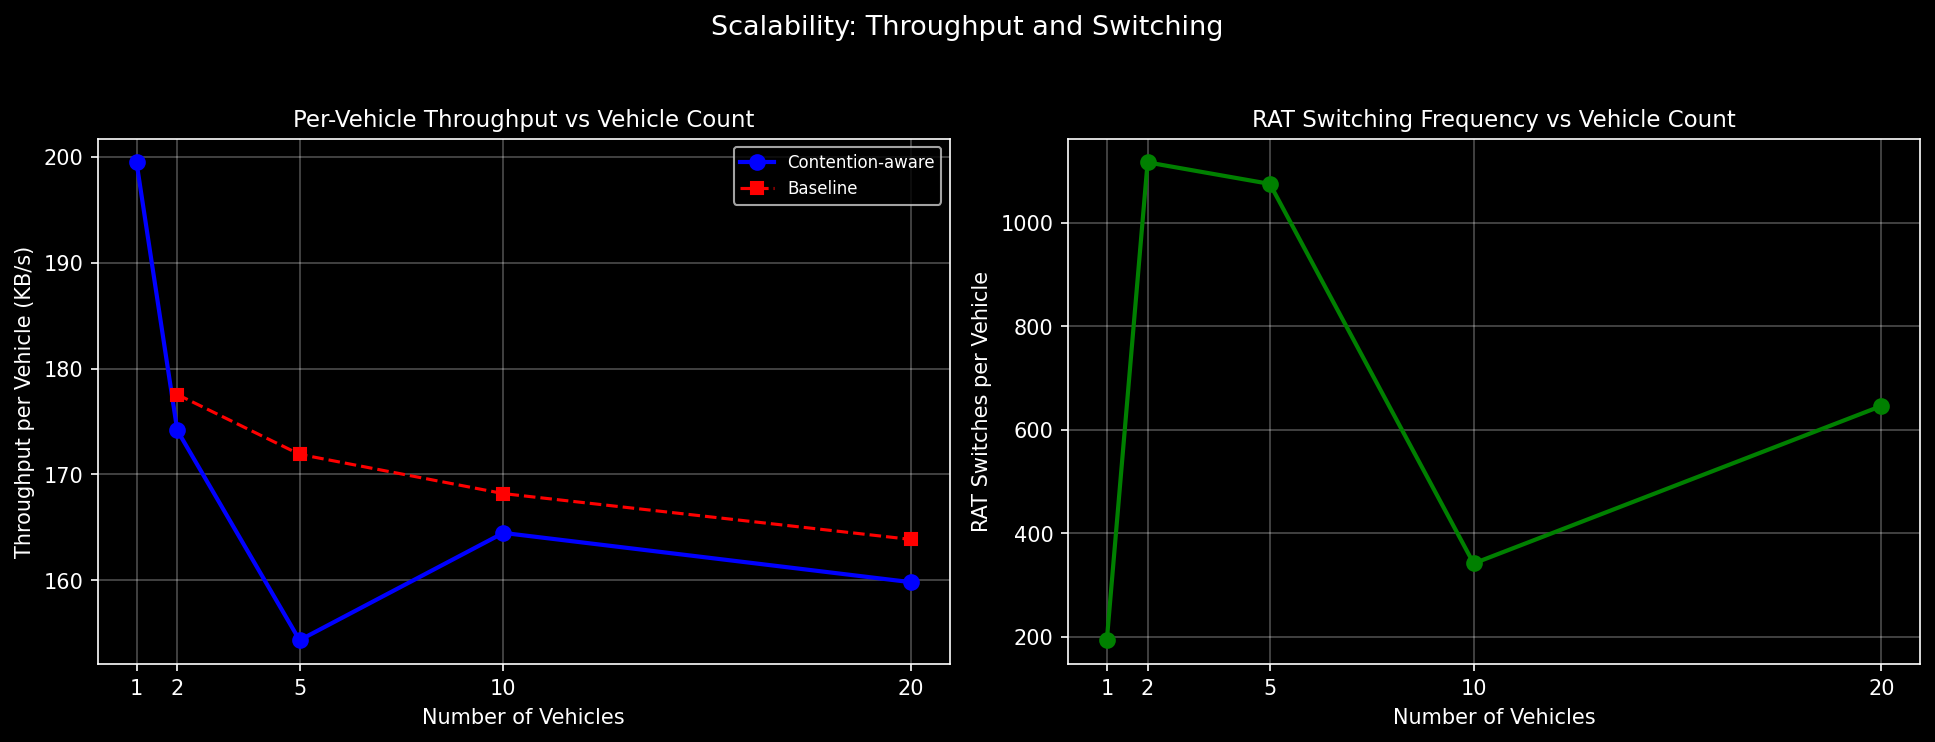

In [22]:
# ── Figure 12: Throughput/Vehicle & RAT Switches vs Number of Vehicles ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

tp_arr = np.array([mv_runs[n]["tp_per_v"] for n in nv_list])
sw_arr = np.array([mv_runs[n]["switches_per_v"] for n in nv_list])

# Baseline throughput
tp_bl = [mv_runs[n]["bl_tp_per_v"] for n in nv_bl] if nv_bl else []

# Throughput/vehicle vs N
ax1.plot(nv_arr, tp_arr, "bo-", lw=2, ms=7, label="Contention-aware")
if tp_bl:
    ax1.plot(nv_bl, tp_bl, "rs--", lw=1.5, ms=6, label="Baseline")
ax1.set_xlabel("Number of Vehicles")
ax1.set_ylabel("Throughput per Vehicle (KB/s)")
ax1.set_title("Per-Vehicle Throughput vs Vehicle Count")
ax1.set_xticks(nv_arr)
ax1.legend()
ax1.grid(True, alpha=0.3)

# RAT switches/vehicle vs N
ax2.plot(nv_arr, sw_arr, "go-", lw=2, ms=7)
ax2.set_xlabel("Number of Vehicles")
ax2.set_ylabel("RAT Switches per Vehicle")
ax2.set_title("RAT Switching Frequency vs Vehicle Count")
ax2.set_xticks(nv_arr)
ax2.grid(True, alpha=0.3)

fig.suptitle("Scalability: Throughput and Switching", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG / "fig12_scalability_throughput_switches.png")
plt.show()


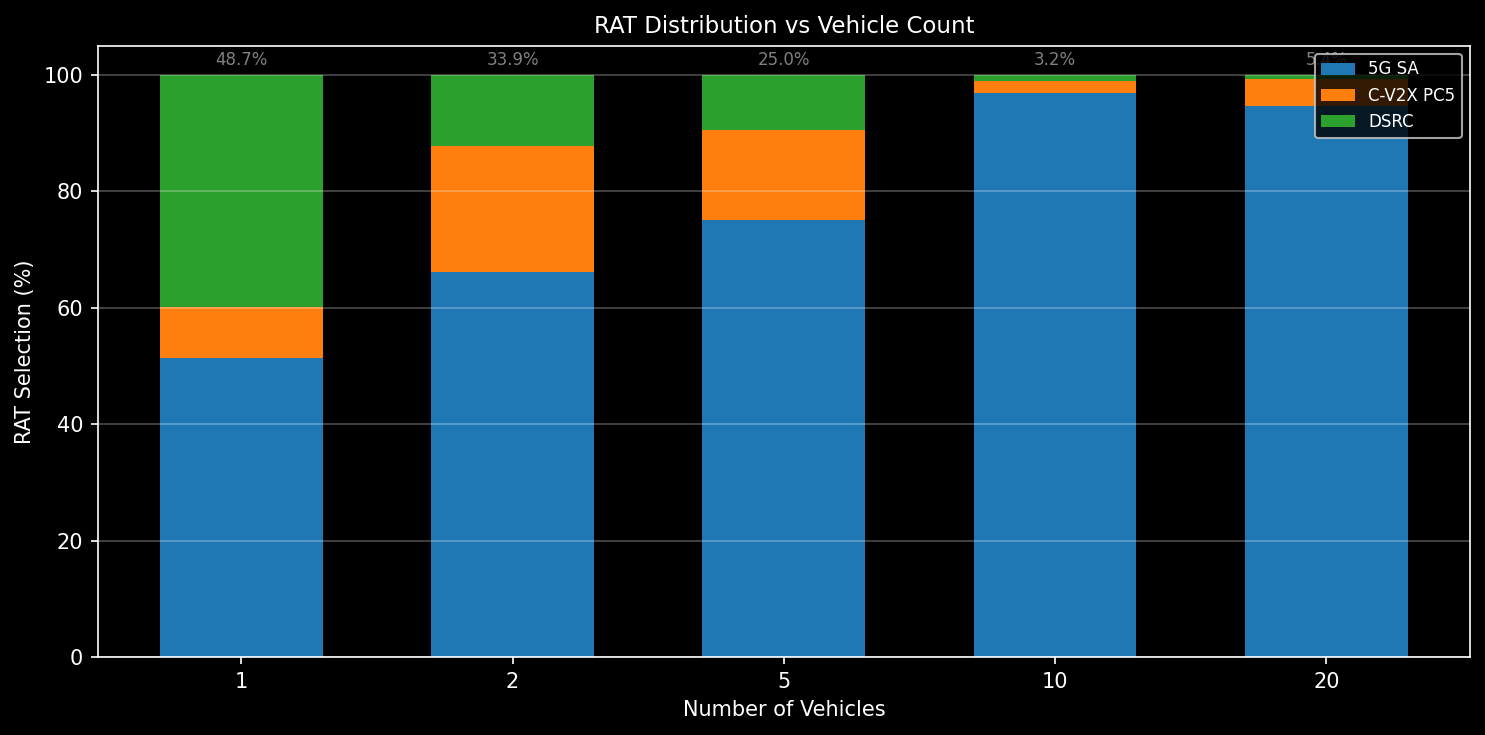

In [23]:
# ── Figure 13: RAT Distribution Shift vs Number of Vehicles ──

fig, ax = plt.subplots(figsize=(10, 5))

pct_5g = [mv_runs[n]["rat_5g_pct"] for n in nv_list]
pct_pc5 = [mv_runs[n]["rat_pc5_pct"] for n in nv_list]
pct_dsrc = [mv_runs[n]["rat_dsrc_pct"] for n in nv_list]

x = np.arange(len(nv_list))
width = 0.6

ax.bar(x, pct_5g, width, label="5G SA", color=RAT_COLORS["5g"])
ax.bar(x, pct_pc5, width, bottom=pct_5g, label="C-V2X PC5", color=RAT_COLORS["pc5"])
ax.bar(x, pct_dsrc, width,
       bottom=[a + b for a, b in zip(pct_5g, pct_pc5)],
       label="DSRC", color=RAT_COLORS["dsrc"])

ax.set_xlabel("Number of Vehicles")
ax.set_ylabel("RAT Selection (%)")
ax.set_title("RAT Distribution vs Vehicle Count")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in nv_list])
ax.legend(loc="upper right")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis="y")

# Annotate PC5+DSRC percentage
for i, n in enumerate(nv_list):
    non_5g = pct_pc5[i] + pct_dsrc[i]
    if non_5g > 2:
        ax.text(i, 101, f"{non_5g:.1f}%", ha="center", va="bottom", fontsize=8, color="gray")

fig.tight_layout()
fig.savefig(FIG / "fig13_rat_distribution_vs_vehicles.png")
plt.show()


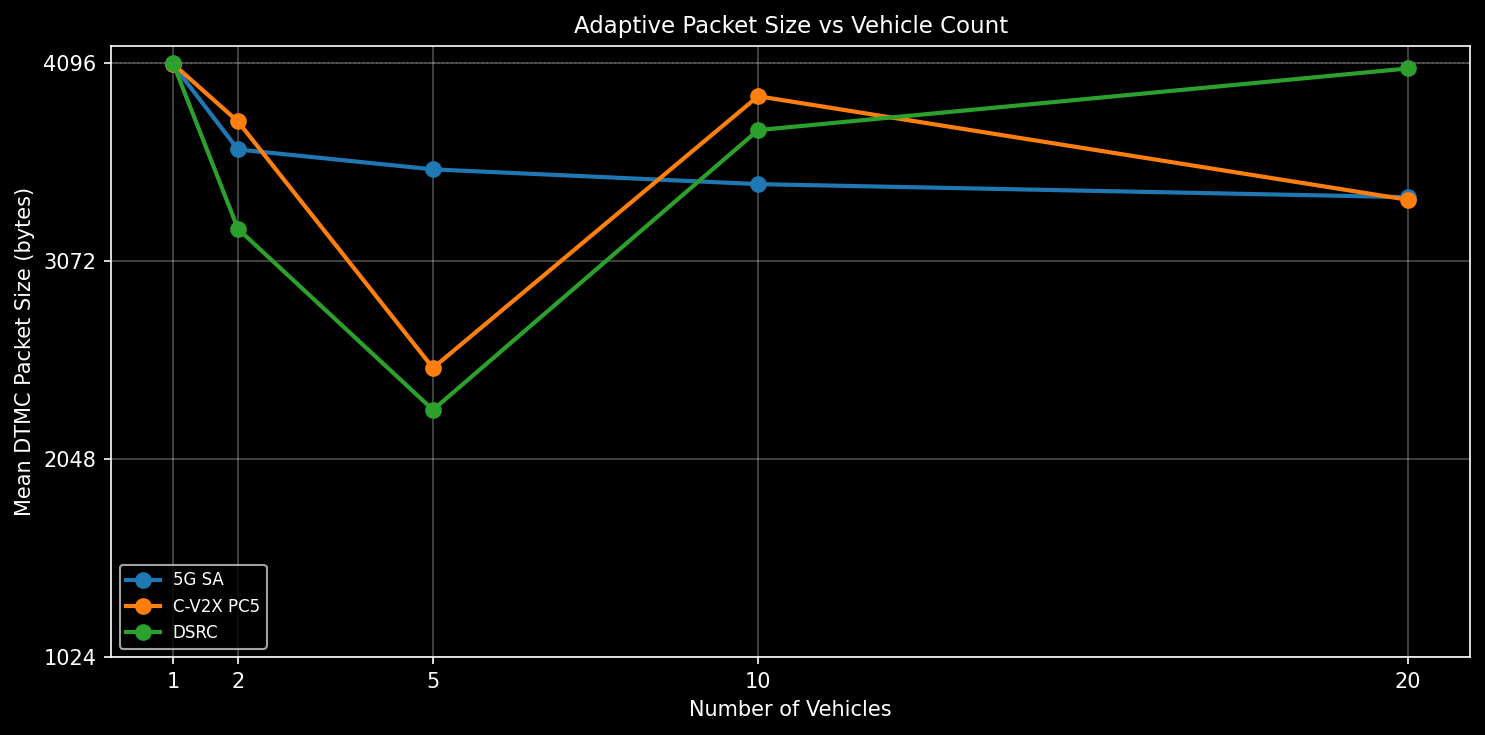

In [24]:
# ── Figure 14: DTMC Mean Packet Size vs Number of Vehicles ──

fig, ax = plt.subplots(figsize=(10, 5))

for rat_key in ["5g", "pc5", "dsrc"]:
    sizes = [mv_runs[n][f"dtmc_{rat_key}"] for n in nv_list]
    ax.plot(nv_arr, sizes, "o-", lw=2, ms=7, color=RAT_COLORS[rat_key],
            label=RAT_LABELS[rat_key])

ax.set_xlabel("Number of Vehicles")
ax.set_ylabel("Mean DTMC Packet Size (bytes)")
ax.set_title("Adaptive Packet Size vs Vehicle Count")
ax.set_xticks(nv_arr)
ax.set_yticks([1024, 2048, 3072, 4096])
ax.axhline(4096, color="gray", ls=":", lw=0.8, alpha=0.5)
ax.axhline(1024, color="gray", ls=":", lw=0.8, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG / "fig14_dtmc_packet_size_vs_vehicles.png")
plt.show()


/tmp/ipykernel_19945/3102624884.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(pv_data, labels=pv_labels, patch_artist=True, showfliers=True,


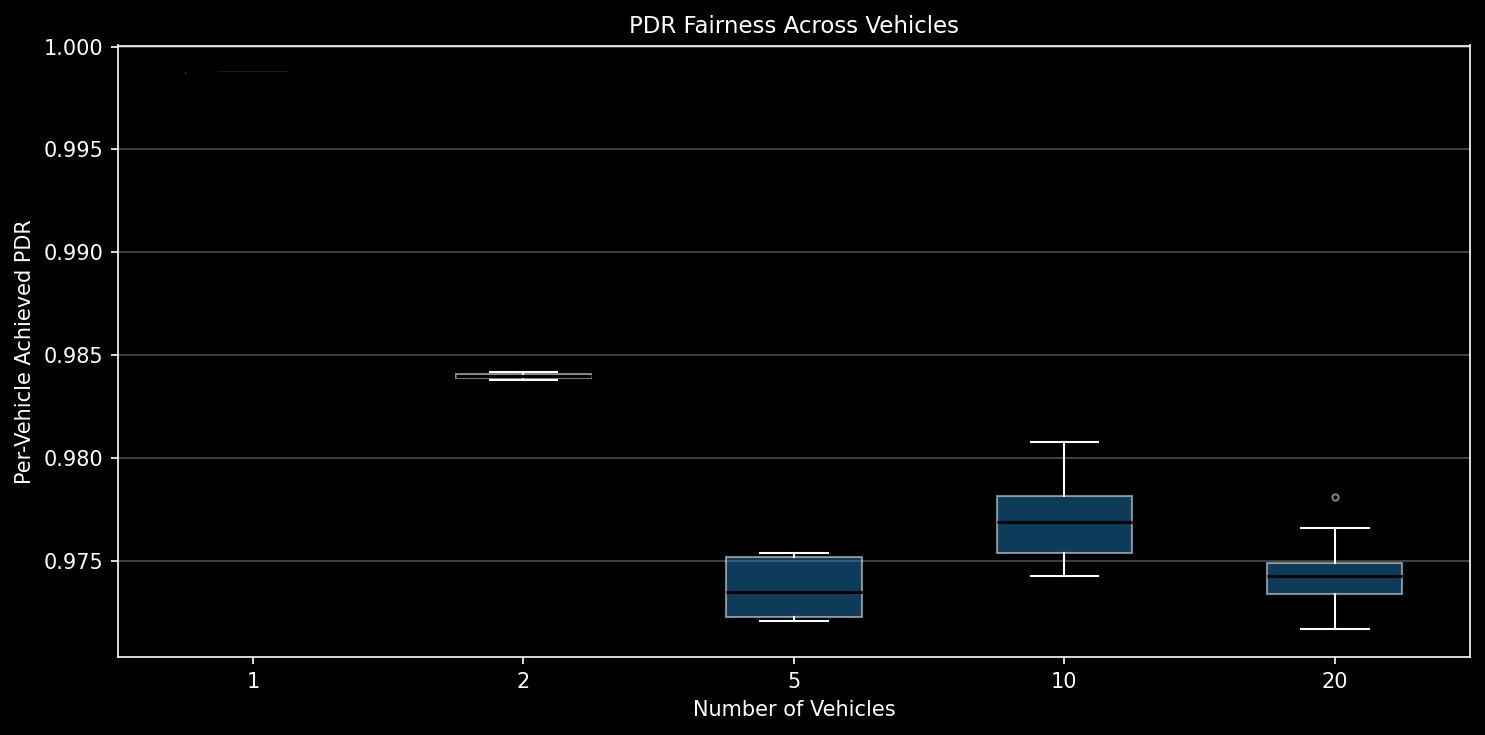

In [25]:
# ── Figure 15: Per-Vehicle PDR Distribution (boxplots) Across Vehicle Counts ──

fig, ax = plt.subplots(figsize=(10, 5))

pv_data = []
pv_labels = []
for nv in nv_list:
    run = mv_runs[nv]
    pv_file = run["dir"] / "feedback_multi_per_vehicle.csv"
    if pv_file.exists():
        pvdf = pd.read_csv(pv_file)
        pv_data.append(pvdf["achieved_pdr"].values)
        pv_labels.append(str(nv))
    elif nv == 1:
        # Single vehicle — just one data point
        pv_data.append(np.array([run["pdr"]]))
        pv_labels.append(str(nv))

bp = ax.boxplot(pv_data, labels=pv_labels, patch_artist=True, showfliers=True,
                medianprops=dict(color="black", lw=1.5),
                flierprops=dict(marker="o", ms=3, alpha=0.5))
for patch in bp["boxes"]:
    patch.set_facecolor("#1f77b4")
    patch.set_alpha(0.5)

ax.set_xlabel("Number of Vehicles")
ax.set_ylabel("Per-Vehicle Achieved PDR")
ax.set_title("PDR Fairness Across Vehicles")
ax.grid(True, alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(FIG / "fig15_pdr_fairness_boxplot.png")
plt.show()


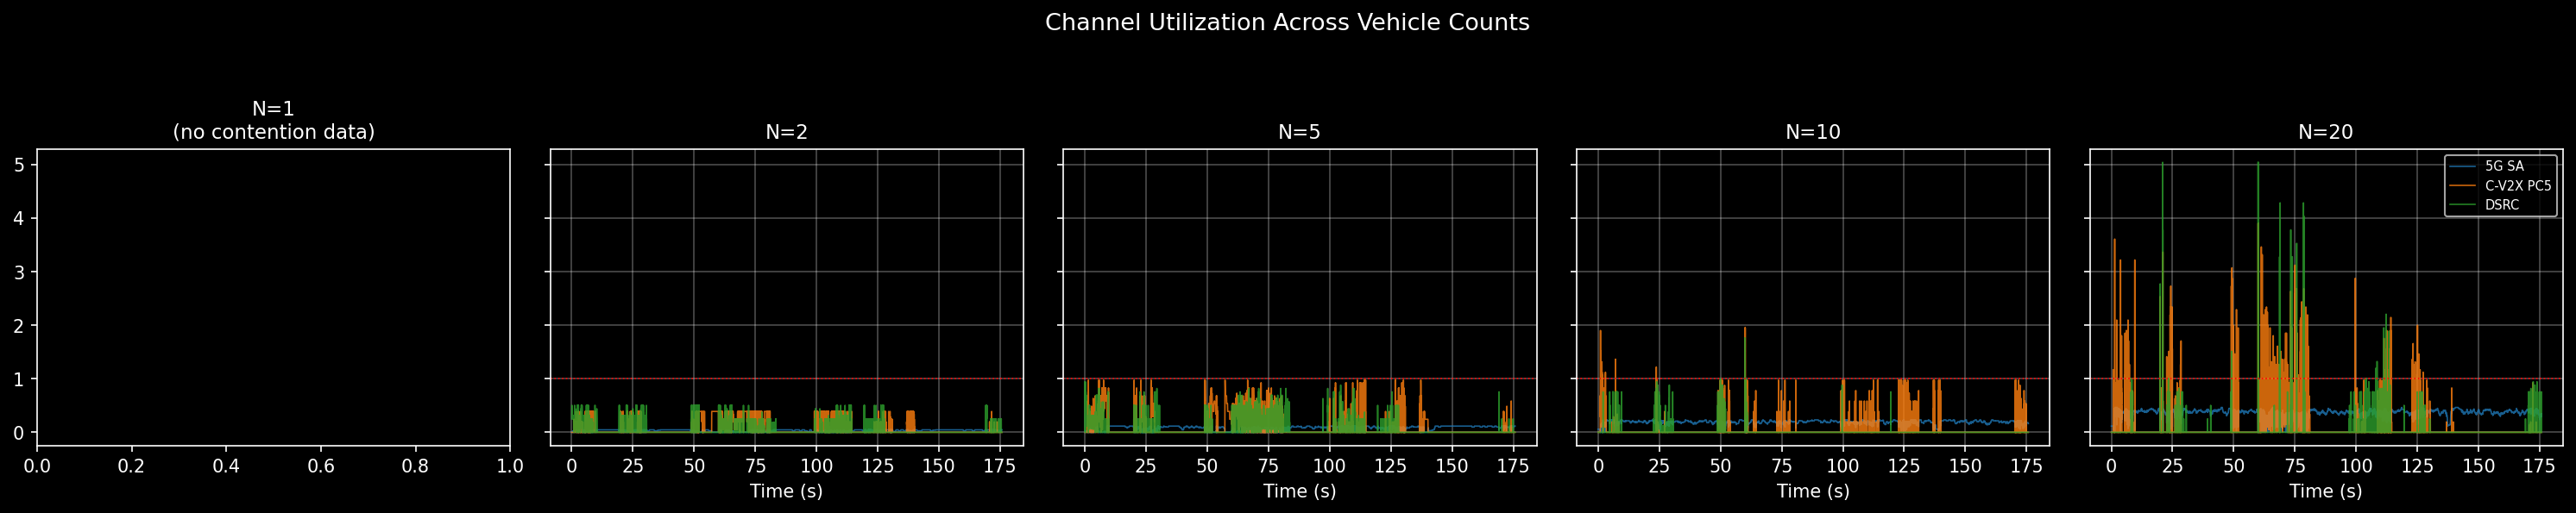

In [26]:
# ── Figure 16: Channel Utilization Comparison Across Vehicle Counts ──

fig, axes = plt.subplots(1, len(nv_list), figsize=(4 * len(nv_list), 4), sharey=True)
if len(nv_list) == 1:
    axes = [axes]

for i, nv in enumerate(nv_list):
    ax = axes[i]
    run = mv_runs[nv]
    cont_file = run["dir"] / "feedback_multi_contention.csv"
    if not cont_file.exists():
        # Try single-vehicle log (no contention file for N=1)
        ax.set_title(f"N={nv}\n(no contention data)")
        continue
    c = pd.read_csv(cont_file)
    for rat_key in ["5g", "pc5", "dsrc"]:
        col = f"utilization_{rat_key}"
        if col in c.columns:
            ax.plot(c["sim_time"], c[col], color=RAT_COLORS[rat_key],
                    label=RAT_LABELS[rat_key], lw=0.8, alpha=0.8)
    ax.axhline(1.0, color="red", ls=":", lw=0.8)
    ax.set_title(f"N={nv}")
    ax.set_xlabel("Time (s)")
    if i == 0:
        ax.set_ylabel("Channel Utilization")
    ax.grid(True, alpha=0.3)
    if i == len(nv_list) - 1:
        ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Channel Utilization Across Vehicle Counts", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG / "fig16_utilization_comparison.png")
plt.show()


In [27]:
# ── Table 3: Multi-Vehicle Scalability Summary ──

table_rows = []
for nv in nv_list:
    e = mv_runs[nv]
    row = {
        "N": nv,
        "PDR": f"{e['pdr']:.4f}",
        "Latency (ms)": f"{e['latency']:.1f}",
        "TP/veh (KB/s)": f"{e['tp_per_v']:.1f}",
        "Switches/veh": f"{e['switches_per_v']:.0f}",
        "5G %": f"{e['rat_5g_pct']:.1f}",
        "PC5 %": f"{e['rat_pc5_pct']:.1f}",
        "DSRC %": f"{e['rat_dsrc_pct']:.1f}",
        "DTMC 5G (B)": f"{e['dtmc_5g']:.0f}",
        "DTMC PC5 (B)": f"{e['dtmc_pc5']:.0f}",
        "DTMC DSRC (B)": f"{e['dtmc_dsrc']:.0f}",
    }
    if "bl_pdr" in e:
        row["BL PDR"] = f"{e['bl_pdr']:.4f}"
        row["BL Lat (ms)"] = f"{e['bl_latency']:.1f}"
    else:
        row["BL PDR"] = "—"
        row["BL Lat (ms)"] = "—"
    table_rows.append(row)

mv_table = pd.DataFrame(table_rows)
print("=== Multi-Vehicle Scalability Summary ===\n")
print(tabulate(mv_table, headers="keys", tablefmt="github", showindex=False))


=== Multi-Vehicle Scalability Summary ===

|   N |    PDR |   Latency (ms) |   TP/veh (KB/s) |   Switches/veh |   5G % |   PC5 % |   DSRC % |   DTMC 5G (B) |   DTMC PC5 (B) |   DTMC DSRC (B) | BL PDR   | BL Lat (ms)   |
|-----|--------|----------------|-----------------|----------------|--------|---------|----------|---------------|----------------|-----------------|----------|---------------|
|   1 | 0.9987 |           19.6 |           199.5 |            193 |   51.3 |     8.8 |     39.8 |          4087 |           4091 |            4095 | —        | —             |
|   2 | 0.984  |           22.6 |           174.2 |           1117 |   66.1 |    21.6 |     12.2 |          3647 |           3792 |            3237 | 0.9874   | 21.5          |
|   5 | 0.9737 |           20.6 |           154.3 |           1075 |   75   |    15.5 |      9.4 |          3545 |           2518 |            2302 | 0.9842   | 21.7          |
|  10 | 0.977  |           22.2 |           164.5 |            341 |   9